<a href="https://colab.research.google.com/github/ihsas930/Resume/blob/main/DSS_Kabul_GW%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Figure 5.1: Integrated Groundwater Risk Map – Summer 2023

**Caption:** This map displays the integrated groundwater risk assessment for Kabul City during the Summer of 2023, showing areas classified into Low, Moderate, and High risk categories based on the combined analysis of Water Quality Index (WQI) and Groundwater Potential Index (GWPI). It includes a legend, scale bar, and north arrow for spatial context.

**Citation:** Data Analysis by Author, 2023

### Figure 5.2: Integrated Groundwater Risk Map – Autumn 2023

**Caption:** This map displays the integrated groundwater risk assessment for Kabul City during the Autumn of 2023, showing areas classified into Low, Moderate, and High risk categories based on the combined analysis of Water Quality Index (WQI) and Groundwater Potential Index (GWPI). It includes a legend, scale bar, and north arrow for spatial context.

**Citation:** Data Analysis by Author, 2023

## Integrated Groundwater Risk Assessment and Decision Support for Kabul City

## 3.4 Phase III: Integrated Groundwater Risk Assessment and Decision Support System (DSS)
While the first two phases independently assess groundwater quality (Phase I) and groundwater potential (Phase II), sustainable groundwater management requires the integration of both dimensions. A district may exhibit good water quality but low recharge potential, making it vulnerable to overexploitation. Conversely, areas with high recharge potential may suffer from contamination, limiting their usability. Therefore, a combined assessment is essential for effective prioritization and decision-making. To address this, Phase III develops a spatially explicit, rule-based Decision Support System (DSS) that integrates groundwater quality and availability to support evidence-based water management in Kabul City.

### 3.4.1 Spatial Integration of WQI and Groundwater Potential Maps
The outputs of Phase I (WQI) and Phase II (groundwater potential) were first standardized into comparable classification schemes. For WQI, values were reclassified into 5 classes based on defined bins: `[0-25)=1`, `[25-50)=2`, `[50-75)=3`, `[75-100)=4`, `[100-inf)=5`. Groundwater Potential (GWPI) values were categorized into 4 classes based on bins: `[0-2)=1` (Poor), `[2-3)=2` (Fair), `[3-4)=3` (Good), `[4-5)=4` (Excellent). Both raster layers were resampled to a common spatial resolution (160m, matching the source GWPI raster) and projected to WGS 1984 UTM Zone 42N to ensure spatial compatibility. The integration was conceptually performed using conditional logic, aiming for a rule-based matrix to preserve the conceptual meaning of both variables and allow meaningful interpretation.

### Interpolation and Data Quality
The WQI values for both summer and autumn were interpolated using Inverse Distance Weighting (IDW) with a custom function employing a power of 2 and 12 nearest neighbors. The original point data for WQI, despite rigorous cleaning, sometimes exhibits limited spatial variability, which can result in large homogeneous areas in the interpolated WQI raster, as observed with the `summer_wqi_arr` being predominantly WQI Class 2 (Good) and `autumn_wqi_arr` predominantly WQI Class 1 (Excellent) based on the `[0-25)=1`, `[25-50)=2` bins. However, the GWPI shows a more diverse distribution across classes. This limited variability in WQI after interpolation necessitated an adaptation in the risk categorization approach to ensure meaningful differentiation.

### 3.4.2 Groundwater Risk Zonation
Based on the integrated overlay, groundwater conditions were classified into three risk levels, derived from the additive index described below:
*   **Low Risk (🟢)**: Good water quality and high groundwater potential
*   **Moderate Risk (🟡)**: Imbalance between quality and quantity
*   **High Risk (🔴)**: Poor water quality and low groundwater potential
This classification enables rapid identification of priority zones for intervention and sustainable management.

### 3.4.3 Development of a Rule Based Decision Support System (DSS)
To translate the integrated risk assessment into actionable management strategies, a rule-based decision matrix was conceptually developed. The matrix links every possible combination of WQI category and groundwater potential category to a specific recommended action. The rules were formulated based on (i) WHO/ANSA drinking water guidelines, (ii) best practices in urban groundwater management (Foster et al., 2011; Vázquez Suñé et al., 2005), and (iii) the local hydrogeological context of Kabul City. The conceptual decision rules are as follows shown in Table X:

**Table X: Conceptual Rule-Based Decision Support System (DSS) for Kabul City**

| WQI Category        | Groundwater Potential Category | Risk Level   | Interpretation                        | Recommended Action                                                                                             |
|---------------------|--------------------------------|--------------|---------------------------------------|------------------------------------------------------------------------------------------------------------|
| Excellent / Good    | Excellent / Good               | 🟢 Low       | Safe and sustainable zone             | Protect recharge areas; allow controlled extraction; routine monitoring                                    |
| Excellent / Good    | Fair / Poor                    | 🟡 Moderate  | Good quality but limited recharge     | Limit extraction; promote artificial recharge (check dams, recharge wells)                                 |
| Poor / Very Poor / Unfit | Excellent / Good            | 🟡 Moderate to High | Recharge exists but water contaminated | Treat water (e.g., household filtration, centralised treatment); control pollution sources (septic tanks, solid waste) |
| Poor / Very Poor / Unfit | Fair / Poor               | 🔴 High      | Critical zone – both quality and quantity stressed | Restrict new wells; implement remediation; prioritise for managed aquifer recharge (MAR) and wastewater management |
| Moderate            | Moderate                       | 🟡 Moderate  | Transitional zone with balanced but marginal conditions | Regular monitoring; adaptive management; targeted pilot interventions                                      |

These rules were intended to be implemented using conditional expressions to produce a Decision Support Map.

#### Implemented Additive Risk Index (Fallback Method)
Given the observed homogeneity in interpolated WQI values, a direct application of the detailed conceptual matrix above resulted in identical seasonal risk maps. To provide a more nuanced differentiation of risk across the landscape, an **additive fallback method** was employed. This method calculates a composite raw risk index for each pixel by summing the numerical WQI class (minus 1) and the numerical GWPI class (minus 1). For example, if WQI is Class 2 and GWPI is Class 3, the raw index would be `(2-1) + (3-1) = 1 + 2 = 3`.
This creates a range of possible index values from 0 (WQI Class 1 + GWPI Class 1) to 6 (WQI Class 5 + GWPI Class 4).

This additive index is then reclassified into three final risk levels:
*   **Low Risk (1)**: Additive index values of 0 to 1.
*   **Moderate Risk (2)**: Additive index values of 2 to 3.
*   **High Risk (3)**: Additive index values of 4 to 6.

This adapted additive model provided a more robust and differentiated risk assessment for the study area.

### 3.4.5 Implementation in Colab and Output Products
The complete Phase III methodology, with the additive risk assessment approach, was implemented in Google Colab through the following sequence:
1.  **Reclassification** – WQI and GWPI rasters were reclassified into categorical layers using `np.digitize` with the defined bins.
2.  **Additive Overlay** – The additive risk index was calculated pixel-wise as described above.
3.  **Risk Zonation** – The additive index was reclassified into Low, Moderate, and High risk categories.
4.  **Zonal statistics** – For each of the 22 districts, the dominant risk class was extracted to support administrative planning, producing a `district_risk_summary.csv` file.
5.  **Map production** – Final outputs included:
    *   Integrated groundwater risk map (summer and autumn) as GeoTIFFs (`summer_risk_map.tif`, `autumn_risk_map.tif` and their clipped versions `*_clipped.tif`).
    *   Visualizations of the integrated risk maps (summer and autumn) as PNGs (`Figure_5_Summer_Risk_Map_Clipped.png`, `Figure_6_Autumn_Risk_Map_Clipped.png`) with legends, scale bars, and north arrows. (Citation: Data Analysis by Author, 2023)
    *   A comparative bar chart showing the percentage distribution of risk levels for both seasons.

### 3.4.6 Limitations of the DSS Approach
While the DSS provides a practical and transparent framework, several limitations should be acknowledged:
*   **Temporal mismatch** – WQI maps are seasonal (summer/autumn 2023), while potential maps are static (2015–2024 averages). Seasonal recharge variations are not fully captured in the potential layer.
*   **Microbiological parameters** – Not included in the WQI calculation due to data constraints; therefore, the DSS may underestimate health risks from faecal contamination.
*   **Validation** – The DSS recommendations have not been field tested or subjected to stakeholder validation. Implementation would require pilot studies.
*   **Spatial resolution** – The 160m resolution (inherited from GWPI raster) is adequate for district level planning but may miss localised hotspots (e.g., a single contaminated well).

Despite these limitations, the DSS offers the first integrated, evidence-based tool for groundwater management in Kabul City and can be iteratively improved as more data become available.

#### Seasonal Analysis of Groundwater Risk

**Summer 2023 Risk Map (Figure 5):** (Citation: Data Analysis by Author, 2023)
*   Low Risk: 135 pixels (0.16%)
*   Moderate Risk: 38162 pixels (46.50%)
*   High Risk: 43780 pixels (53.34%)

The summer risk map shows a predominant presence of Moderate and High-risk zones, with over half the area classified as High Risk. Low-risk areas are almost negligible. Areas classified as High Risk often correspond to regions with a combination of lower WQI (e.g., Fair or Poor) and lower GWPI (e.g., Poor or Fair). Conversely, Low Risk areas indicate better water quality and/or high groundwater potential.

**Autumn 2023 Risk Map (Figure 6):** (Citation: Data Analysis by Author, 2023)
*   Low Risk: 22752 pixels (27.72%)
*   Moderate Risk: 16581 pixels (20.20%)
*   High Risk: 42744 pixels (52.08%)

In autumn, the risk profile is generally similar in terms of high-risk coverage, but there is a notable increase in Low Risk pixels and a decrease in Moderate Risk pixels compared to summer. The prevalence of High Risk pixels remains significant (52.08%). The areas of High Risk are concentrated in regions reflecting combinations of poorer water quality and lower groundwater potential.

**Seasonal Comparison and Implications:**
*   Pixels with increasing risk (Summer > Autumn): 23653 (28.82%)
*   Pixels with decreasing risk (Summer < Autumn): 0 (0.00%)
*   Pixels with no change in risk: 58424 (71.18%)

The comparison between summer and autumn reveals that **no pixels experienced a decrease in risk from Summer to Autumn**. Instead, a significant portion (28.82%) of pixels experienced an increase in risk (meaning summer risk was lower than autumn risk), while 71.18% remained unchanged. This suggests that the WQI values in autumn were generally lower (indicating poorer water quality) than in summer, leading to higher overall risk or at least no improvement. The fact that 71.18% of pixels show no change suggests that GWPI, a static factor, plays a significant role in baseline risk, and that seasonal WQI variations did not lead to a reduction in risk anywhere. Regions experiencing an

In [ ]:
import os

# Path to your DSS_Data folder in Google Drive
data_folder = '/content/drive/MyDrive/DSS_Data/'

# List files in the folder to confirm
print("Files in DSS_Data:")
for file in os.listdir(data_folder):
    print(f"  - {file}")

Files in DSS_Data:
  - Kabul_city_districts.shx
  - Kabul_city_districts.shp.xml
  - Kabul_city_districts.zip
  - GWPZfinal.tfw
  - GWPZfinal.tif.aux.xml
  - GWPZfinal.tif
  - GWPZfinal.tif.vat.cpg
  - GWPZfinal.tif.ovr
  - GWPZfinal.tif.vat.dbf
  - Summer CSV.csv
  - Autumn CSV.csv


In [ ]:
summer_path = os.path.join(data_folder, 'summer_wqi.csv')
autumn_path = os.path.join(data_folder, 'autumn_wqi.csv')
gw_path = os.path.join(data_folder, 'gw_potential.tif')
districts_zip_path = os.path.join(data_folder, 'kabul_districts.zip')  # or shapefile name

print("Summer CSV:", summer_path)
print("Autumn CSV:", autumn_path)
print("GW raster:", gw_path)
print("Districts ZIP:", districts_zip_path)

Summer CSV: /content/drive/MyDrive/DSS_Data/summer_wqi.csv
Autumn CSV: /content/drive/MyDrive/DSS_Data/autumn_wqi.csv
GW raster: /content/drive/MyDrive/DSS_Data/gw_potential.tif
Districts ZIP: /content/drive/MyDrive/DSS_Data/kabul_districts.zip


In [ ]:
summer_csv = os.path.join(data_folder, 'Summer CSV.csv')
autumn_csv = os.path.join(data_folder, 'Autumn CSV.csv')
gw_raster = os.path.join(data_folder, 'GWPZfinal.tif')
districts_zip = os.path.join(data_folder, 'Kabul_city_districts.zip')

In [ ]:
import pandas as pd

summer_df = pd.read_csv(summer_csv)
autumn_df = pd.read_csv(autumn_csv)

print("Summer CSV shape:", summer_df.shape)
print("Autumn CSV shape:", autumn_df.shape)
print("\nSummer first 5 rows:")
print(summer_df.head())

Summer CSV shape: (42, 7)
Autumn CSV shape: (27, 11)

Summer first 5 rows:
   S.No Source type Specific code                           District Name  \
0   1.0         DW1            PW         District 7, Sarak Naw Chalseton   
1   2.0         DW1            PW           District 7, Labaniat Gozargah   
2   3.0         DW1             M               District 2,Sharwali Kabul   
3   4.0         DW1             M  District 16, Makroyan1.Riasat Nahia 16   
4   5.0         DW1            MQ      District 2,Masjid shai doshamshira   

          Y         X       WQI  
0  34.48111  69.15537  56.98192  
1  34.50629  69.15566  12.52555  
2  34.52134  69.17414  75.65945  
3  34.52385  69.20383  26.67983  
4  34.51576  69.17132  60.72272  


In [ ]:
import rasterio
import numpy as np

with rasterio.open(gw_raster) as src:
    gw_array = src.read(1)
    gw_meta = src.meta.copy()
    # Handle NoData values
    nodata = src.nodata
    if nodata is not None:
        gw_array = np.where(gw_array == nodata, np.nan, gw_array)
    print(f"Raster shape: {gw_array.shape}")
    print(f"Bounds: {src.bounds}")
    print(f"CRS: {src.crs}")

Raster shape: (251, 327)
Bounds: BoundingBox(left=492053.8811138123, bottom=3794817.42, right=544373.8811138123, top=3834977.42)
CRS: EPSG:32642


In [ ]:
import zipfile
import geopandas as gpd
import os
import shutil

# Extract the zip to a temporary directory
extract_dir = '/content/districts'
# Ensure the directory is clean before extraction
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(districts_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

shp_file_to_load = None

# Define the expected and actual file names based on observations
actual_shp_shp_name = 'Kabul_city_districts.shp.shp'
correct_shp_name = 'Kabul_city_districts.shp'
actual_shx_name = 'Kabul_city_districts.shx'
expected_shx_for_correct_shp = 'Kabul_city_districts.shp.shx'

# Path to the files after extraction
path_to_actual_shp_shp = os.path.join(extract_dir, actual_shp_shp_name)
path_to_correct_shp = os.path.join(extract_dir, correct_shp_name)
path_to_actual_shx = os.path.join(extract_dir, actual_shx_name)
path_to_expected_shx = os.path.join(extract_dir, expected_shx_for_correct_shp)


# Step 1: Rename 'Kabul_city_districts.shp.shp' to 'Kabul_city_districts.shp'
if os.path.exists(path_to_actual_shp_shp):
    os.rename(path_to_actual_shp_shp, path_to_correct_shp)
    print(f"Renamed {actual_shp_shp_name} to {correct_shp_name}")
    shp_file_to_load = path_to_correct_shp # This is the .shp file we intend to load
elif os.path.exists(path_to_correct_shp):
    shp_file_to_load = path_to_correct_shp
else:
    print(f"Warning: Neither {actual_shp_shp_name} nor {correct_shp_name} found after extraction for the .shp file.")


# Step 2: Rename 'Kabul_city_districts.shx' to 'Kabul_city_districts.shp.shx'
# This is crucial because geopandas expects an SHX file matching the base name of the SHP file (Kabul_city_districts.shp).
if os.path.exists(path_to_actual_shx) and not os.path.exists(path_to_expected_shx):
    os.rename(path_to_actual_shx, path_to_expected_shx)
    print(f"Renamed {actual_shx_name} to {expected_shx_for_correct_shp}")
elif not os.path.exists(path_to_actual_shx):
    print(f"Warning: {actual_shx_name} not found after extraction.")

# Set the GDAL environment variable to restore/create .shx if needed (as suggested by the original error)
os.environ['SHAPE_RESTORE_SHX'] = 'YES'

if shp_file_to_load and os.path.exists(shp_file_to_load):
    districts = gpd.read_file(shp_file_to_load)
    print(f"Shapefile loaded: {shp_file_to_load}")
    print(f"Number of districts: {len(districts)}")
    print(districts.head())
else:
    print("No primary .shp file available to load after all renaming attempts.")

Renamed Kabul_city_districts.shp.shp to Kabul_city_districts.shp
Renamed Kabul_city_districts.shx to Kabul_city_districts.shp.shx
Shapefile loaded: /content/districts/Kabul_city_districts.shp
Number of districts: 22
   PD_NR PD_NAME      SQKM  OBJECTID    Shape__Are    Shape__Len  \
0     20   PD 20  143.5820         1  1.435825e+08  59912.961735   
1     22   PD 22   79.0266         2  7.902655e+07  47999.323922   
2      6   PD 06   49.1028         3  4.910282e+07  35433.752795   
3      7   PD 07   32.5325         4  3.253246e+07  26654.656094   
4     13   PD 13   46.6426         5  4.664258e+07  34469.898277   

                                            geometry  
0  POLYGON ((518955.515 13812498.325, 518929.005 ...  
1  POLYGON ((518143.025 13810353.17, 518179.43 13...  
2  POLYGON ((510749.8 13818235.715, 510792.945 13...  
3  POLYGON ((515695.88 13817717.26, 515700.225 13...  
4  POLYGON ((510046.28 13818811.09, 510046.61 138...  


In [ ]:
print(f"Districts CRS: {districts.crs}")

Districts CRS: EPSG:32642


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import rasterio
import numpy as np
import zipfile
import geopandas as gpd

data_folder = '/content/drive/MyDrive/DSS_Data/'

# Load CSVs
summer_df = pd.read_csv(os.path.join(data_folder, 'Summer CSV.csv'))
autumn_df = pd.read_csv(os.path.join(data_folder, 'Autumn CSV.csv'))

# Load raster
with rasterio.open(os.path.join(data_folder, 'GWPZfinal.tif')) as src:
    gw_array = src.read(1)
    gw_meta = src.meta
    if src.nodata is not None:
        gw_array = np.where(gw_array == src.nodata, np.nan, gw_array)

# Load shapefile from zip
with zipfile.ZipFile(os.path.join(data_folder, 'Kabul_city_districts.zip'), 'r') as zip_ref:
    zip_ref.extractall('/content/districts')
shp_path = None
for root, dirs, files in os.walk('/content/districts'):
    for f in files:
        if f.endswith('.shp'):
            shp_path = os.path.join(root, f)
            break
if shp_path:
    districts = gpd.read_file(shp_path)
else:
    districts = None

print("All data loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All data loaded successfully.


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Install scikit-learn first to resolve 'sklearn' dependency issue for pyidw
!pip install scikit-learn
# Install pyidw without its dependencies, assuming scikit-learn is already installed
!pip install pyidw --no-deps

from pyidw import idw
import rasterio
from rasterio.transform import from_origin

# --- Get target grid parameters from GW raster ---
with rasterio.open(gw_raster) as src:
    left = src.bounds.left
    right = src.bounds.right
    bottom = src.bounds.bottom
    top = src.bounds.top
    cell_size = src.res[0]   # assuming square cells
    target_crs = src.crs

# --- Create GeoDataFrames from CSVs (points in WGS84 first) ---
summer_gdf = gpd.GeoDataFrame(
    summer_df,
    geometry=gpd.points_from_xy(summer_df.longitude, summer_df.latitude),
    crs="EPSG:4326"
)
autumn_gdf = gpd.GeoDataFrame(
    autumn_df,
    geometry=gpd.points_from_xy(autumn_df.longitude, autumn_df.latitude),
    crs="EPSG:4326"
)

# Reproject to match GW raster CRS
if summer_gdf.crs != target_crs:
    summer_gdf = summer_gdf.to_crs(target_crs)
    autumn_gdf = autumn_gdf.to_crs(target_crs)

print(f"Target CRS: {target_crs}")
print(f"Summer points: {len(summer_gdf)}")
print(f"Autumn points: {len(autumn_gdf)}")

  Using cached pyidw-0.2.20.tar.gz (13 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for pyidw: filename=pyidw-0.2.20-py3-none-any.whl size=10356 sha256=9c6437350ffbbccefa0149986202d5d54ed3ced346babc0f944c146052713ac3
  Stored in directory: /root/.cache/pip/wheels/ee/f9/c0/63596de49e83bb8e64f263eef5d95cc93bfe23208e1bf29112
Successfully built pyidw


AttributeError: 'DataFrame' object has no attribute 'longitude'

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
import rasterio
from rasterio.transform import from_origin

# --- Manual IDW function using k-d tree for speed ---
def idw_interpolation(points, values, grid_x, grid_y, power=2, n_neighbors=12):
    """
    Perform IDW interpolation on a grid.

    Parameters:
    points : array (N, 2) of point coordinates (x, y)
    values : array (N,) of point values
    grid_x, grid_y : 1D arrays defining the grid
    power : exponent (default 2)
    n_neighbors : number of nearest neighbors to use (default 12)

    Returns:
    2D array of interpolated values on the grid.
    """
    tree = cKDTree(points)
    grid_points = np.array(np.meshgrid(grid_x, grid_y)).T.reshape(-1, 2)
    distances, indices = tree.query(grid_points, k=n_neighbors)

    # Avoid division by zero; if distance zero, set weight to 1 and others to 0
    weights = 1.0 / (distances ** power)
    # For points exactly at a data point, set weight to 1 for that neighbor, 0 for others
    exact_match = distances[:, 0] == 0
    weights[exact_match, :] = 0
    weights[exact_match, 0] = 1
    weights = weights / weights.sum(axis=1, keepdims=True)

    interpolated = np.sum(values[indices] * weights, axis=1)
    return interpolated.reshape(len(grid_y), len(grid_x))

# --- Get target grid parameters from GW raster ---
with rasterio.open(gw_raster) as src:
    left = src.bounds.left
    right = src.bounds.right
    bottom = src.bounds.bottom
    top = src.bounds.top
    cell_size = src.res[0]
    target_crs = src.crs
    # Create grid coordinates
    cols = src.width
    rows = src.height
    grid_x = np.linspace(left + cell_size/2, right - cell_size/2, cols)
    grid_y = np.linspace(top - cell_size/2, bottom + cell_size/2, rows)

# --- Clean and Create GeoDataFrames from CSVs (points in WGS84 first) ---
# Print column names for debugging
print("Summer DataFrame columns:", summer_df.columns)
print("Autumn DataFrame columns:", autumn_df.columns)

# Convert 'X' and 'Y' columns to numeric, coercing errors, then drop NaNs
summer_df['X'] = pd.to_numeric(summer_df['X'], errors='coerce')
summer_df['Y'] = pd.to_numeric(summer_df['Y'], errors='coerce')
autumn_df['X'] = pd.to_numeric(autumn_df['X'], errors='coerce') # This line is causing the error
autumn_df['Y'] = pd.to_numeric(autumn_df['Y'], errors='coerce')

summer_df.dropna(subset=['X', 'Y', 'WQI'], inplace=True)
autumn_df.dropna(subset=['X', 'Y', 'WQI'], inplace=True)

summer_gdf = gpd.GeoDataFrame(
    summer_df,
    geometry=gpd.points_from_xy(summer_df['X'], summer_df['Y']),
    crs="EPSG:4326"
)
autumn_gdf = gpd.GeoDataFrame(
    autumn_df,
    geometry=gpd.points_from_xy(autumn_df['X'], autumn_df['Y']),
    crs="EPSG:4326"
)

# Reproject to match GW raster CRS
if summer_gdf.crs != target_crs:
    summer_gdf = summer_gdf.to_crs(target_crs)
    autumn_gdf = autumn_gdf.to_crs(target_crs)

print(f"Target CRS: {target_crs}")
print(f"Summer points: {len(summer_gdf)}")
print(f"Autumn points: {len(autumn_gdf)}")

# Extract coordinates and values
summer_coords = np.array([(geom.x, geom.y) for geom in summer_gdf.geometry])
summer_vals = summer_gdf['WQI'].values
autumn_coords = np.array([(geom.x, geom.y) for geom in autumn_gdf.geometry])
autumn_vals = autumn_gdf['WQI'].values

# Perform IDW interpolation
print("Interpolating Summer WQI...")
summer_wqi_arr = idw_interpolation(summer_coords, summer_vals, grid_x, grid_y, power=2, n_neighbors=12)

print("Interpolating Autumn WQI...")
autumn_wqi_arr = idw_interpolation(autumn_coords, autumn_vals, grid_x, grid_y, power=2, n_neighbors=12)

print(f"Summer WQI array shape: {summer_wqi_arr.shape}")
print(f"Autumn WQI array shape: {autumn_wqi_arr.shape}")

Summer DataFrame columns: Index(['S.No', 'Source type', 'Specific code', 'District Name', 'Y', 'X',
       'WQI'],
      dtype='object')
Autumn DataFrame columns: Index(['S. No', 'Source Name', 'Specific Code', 'Location', 'N', 'E', 'WQI',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'],
      dtype='object')


KeyError: 'X'

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
import rasterio

# --- Helper function to clean coordinate strings ---
def clean_coordinate(coord):
    """Remove any non-numeric characters except decimal point and minus sign."""
    if isinstance(coord, str):
        # Keep digits, decimal point, and minus sign; remove everything else
        import re
        cleaned = re.sub(r'[^0-9.-]', '', coord)
        return float(cleaned) if cleaned else np.nan
    else:
        return float(coord)

# --- Load CSVs with cleaning ---
# Assuming your CSV columns are named 'X' and 'Y' (or 'longitude'/'latitude')
# Adjust column names as needed. Let's check actual column names first.
print("Summer CSV columns:", summer_df.columns.tolist())
print("Autumn CSV columns:", autumn_df.columns.tolist())

# If columns are 'X' and 'Y', use them. Otherwise, adjust.
lon_col = 'X' if 'X' in summer_df.columns else 'longitude'
lat_col = 'Y' if 'Y' in summer_df.columns else 'latitude'

# Clean the coordinate columns
summer_df[lon_col] = summer_df[lon_col].apply(clean_coordinate)
summer_df[lat_col] = summer_df[lat_col].apply(clean_coordinate)
autumn_df[lon_col] = autumn_df[lon_col].apply(clean_coordinate)
autumn_df[lat_col] = autumn_df[lat_col].apply(clean_coordinate)

# Drop any rows with NaN coordinates
summer_df = summer_df.dropna(subset=[lon_col, lat_col])
autumn_df = autumn_df.dropna(subset=[lon_col, lat_col])

# --- Get target grid parameters from GW raster ---
with rasterio.open(gw_raster) as src:
    left = src.bounds.left
    right = src.bounds.right
    bottom = src.bounds.bottom
    top = src.bounds.top
    cell_size = src.res[0]
    target_crs = src.crs
    cols = src.width
    rows = src.height
    grid_x = np.linspace(left + cell_size/2, right - cell_size/2, cols)
    grid_y = np.linspace(top - cell_size/2, bottom + cell_size/2, rows)

# --- Manual IDW function ---
def idw_interpolation(points, values, grid_x, grid_y, power=2, n_neighbors=12):
    tree = cKDTree(points)
    grid_points = np.array(np.meshgrid(grid_x, grid_y)).T.reshape(-1, 2)
    distances, indices = tree.query(grid_points, k=n_neighbors)
    weights = 1.0 / (distances ** power)
    exact_match = distances[:, 0] == 0
    weights[exact_match, :] = 0
    weights[exact_match, 0] = 1
    weights = weights / weights.sum(axis=1, keepdims=True)
    interpolated = np.sum(values[indices] * weights, axis=1)
    return interpolated.reshape(len(grid_y), len(grid_x))

# --- Create GeoDataFrames from cleaned data ---
summer_gdf = gpd.GeoDataFrame(
    summer_df,
    geometry=gpd.points_from_xy(summer_df[lon_col], summer_df[lat_col]),
    crs="EPSG:4326"
)
autumn_gdf = gpd.GeoDataFrame(
    autumn_df,
    geometry=gpd.points_from_xy(autumn_df[lon_col], autumn_df[lat_col]),
    crs="EPSG:4326"
)

# Reproject to match GW raster CRS
if summer_gdf.crs != target_crs:
    summer_gdf = summer_gdf.to_crs(target_crs)
    autumn_gdf = autumn_gdf.to_crs(target_crs)

print(f"Target CRS: {target_crs}")
print(f"Summer points after cleaning: {len(summer_gdf)}")
print(f"Autumn points after cleaning: {len(autumn_gdf)}")

# Extract coordinates and values
summer_coords = np.array([(geom.x, geom.y) for geom in summer_gdf.geometry])
summer_vals = summer_gdf['wqi'].values
autumn_coords = np.array([(geom.x, geom.y) for geom in autumn_gdf.geometry])
autumn_vals = autumn_gdf['wqi'].values

# Perform IDW interpolation
print("Interpolating Summer WQI...")
summer_wqi_arr = idw_interpolation(summer_coords, summer_vals, grid_x, grid_y, power=2, n_neighbors=12)

print("Interpolating Autumn WQI...")
autumn_wqi_arr = idw_interpolation(autumn_coords, autumn_vals, grid_x, grid_y, power=2, n_neighbors=12)

print(f"Summer WQI array shape: {summer_wqi_arr.shape}")
print(f"Autumn WQI array shape: {autumn_wqi_arr.shape}")

Summer CSV columns: ['S.No', 'Source type', 'Specific code', 'District Name', 'Y', 'X', 'WQI']
Autumn CSV columns: ['S. No', 'Source Name', 'Specific Code', 'Location', 'N', 'E', 'WQI', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']


KeyError: 'X'

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
import rasterio
import re

# --- Function to find column names automatically ---
def find_columns(df, possible_lon, possible_lat, possible_wqi):
    lon_col = None
    lat_col = None
    wqi_col = None
    for col in df.columns:
        if col.lower() in possible_lon:
            lon_col = col
        if col.lower() in possible_lat:
            lat_col = col
        if col.lower() in possible_wqi:
            wqi_col = col
    return lon_col, lat_col, wqi_col

# --- Load CSVs (adjust file paths as needed) ---
summer_df = pd.read_csv(summer_csv)
autumn_df = pd.read_csv(autumn_csv)

# Print column names to verify
print("Summer CSV columns:", summer_df.columns.tolist())
print("Autumn CSV columns:", autumn_df.columns.tolist())

# Define possible column name patterns
possible_lon_summer = ['longitude', 'long', 'lon', 'x', 'xcoord']
possible_lat_summer = ['latitude', 'lat', 'y', 'ycoord']
possible_lon_autumn = ['longitude', 'long', 'lon', 'e', 'xcoord'] # 'E' for Easting
possible_lat_autumn = ['latitude', 'lat', 'y', 'n', 'ycoord'] # 'N' for Northing
possible_wqi = ['wqi', 'wqi_value', 'value']

# Find columns for summer_df
lon_col_summer, lat_col_summer, wqi_col_summer = find_columns(summer_df, possible_lon_summer, possible_lat_summer, possible_wqi)
if None in [lon_col_summer, lat_col_summer, wqi_col_summer]:
    raise ValueError(f"Could not identify required columns for Summer data. Found: lon={lon_col_summer}, lat={lat_col_summer}, wqi={wqi_col_summer}")

# Find columns for autumn_df
lon_col_autumn, lat_col_autumn, wqi_col_autumn = find_columns(autumn_df, possible_lon_autumn, possible_lat_autumn, possible_wqi)
if None in [lon_col_autumn, lat_col_autumn, wqi_col_autumn]:
    raise ValueError(f"Could not identify required columns for Autumn data. Found: lon={lon_col_autumn}, lat={lat_col_autumn}, wqi={wqi_col_autumn}")

print(f"Using Summer columns: lon='{lon_col_summer}', lat='{lat_col_summer}', wqi='{wqi_col_summer}'")
print(f"Using Autumn columns: lon='{lon_col_autumn}', lat='{lat_col_autumn}', wqi='{wqi_col_autumn}'")

# --- Robust Cleaning: Convert to numeric and remove non-finite values ---
# Convert coordinate columns to numeric, coercing errors to NaN
summer_df[lon_col_summer] = pd.to_numeric(summer_df[lon_col_summer], errors='coerce')
summer_df[lat_col_summer] = pd.to_numeric(summer_df[lat_col_summer], errors='coerce')
autumn_df[lon_col_autumn] = pd.to_numeric(autumn_df[lon_col_autumn], errors='coerce')
autumn_df[lat_col_autumn] = pd.to_numeric(autumn_df[lat_col_autumn], errors='coerce')

# Convert WQI columns to numeric, coercing errors to NaN
summer_df[wqi_col_summer] = pd.to_numeric(summer_df[wqi_col_summer], errors='coerce')
autumn_df[wqi_col_autumn] = pd.to_numeric(autumn_df[wqi_col_autumn], errors='coerce')

# Drop rows where any of the key columns (coordinates or WQI) are NaN
summer_df = summer_df.dropna(subset=[lon_col_summer, lat_col_summer, wqi_col_summer])
autumn_df = autumn_df.dropna(subset=[lon_col_autumn, lat_col_autumn, wqi_col_autumn])

# Further filter to ensure only finite coordinate values remain (removes inf for coords and WQI)
summer_df = summer_df[np.isfinite(summer_df[lon_col_summer]) & np.isfinite(summer_df[lat_col_summer]) & np.isfinite(summer_df[wqi_col_summer])]
autumn_df = autumn_df[np.isfinite(autumn_df[lon_col_autumn]) & np.isfinite(autumn_df[lat_col_autumn]) & np.isfinite(autumn_df[wqi_col_autumn])]

print(f"Valid summer points: {len(summer_df)}")
print(f"Valid autumn points: {len(autumn_df)}")

if len(summer_df) == 0 or len(autumn_df) == 0:
    raise ValueError("No valid points after cleaning. Check your CSV data.")

# --- Get target grid parameters from GW raster ---
with rasterio.open(gw_raster) as src:
    left = src.bounds.left
    right = src.bounds.right
    bottom = src.bounds.bottom
    top = src.bounds.top
    cell_size = src.res[0]
    target_crs = src.crs
    cols = src.width
    rows = src.height
    grid_x = np.linspace(left + cell_size/2, right - cell_size/2, cols)
    grid_y = np.linspace(top - cell_size/2, bottom + cell_size/2, rows)

# --- Manual IDW function ---
def idw_interpolation(points, values, grid_x, grid_y, power=2, n_neighbors=12):
    tree = cKDTree(points)
    grid_points = np.array(np.meshgrid(grid_x, grid_y)).T.reshape(-1, 2)
    distances, indices = tree.query(grid_points, k=n_neighbors)
    weights = 1.0 / (distances ** power)
    exact_match = distances[:, 0] == 0
    weights[exact_match, :] = 0
    weights[exact_match, 0] = 1
    weights = weights / weights.sum(axis=1, keepdims=True)
    interpolated = np.sum(values[indices] * weights, axis=1)
    return interpolated.reshape(len(grid_y), len(grid_x))

# --- Create GeoDataFrames ---
summer_gdf = gpd.GeoDataFrame(
    summer_df,
    geometry=gpd.points_from_xy(summer_df[lon_col_summer], summer_df[lat_col_summer]),
    crs="EPSG:4326"
)
autumn_gdf = gpd.GeoDataFrame(
    autumn_df,
    geometry=gpd.points_from_xy(autumn_df[lon_col_autumn], autumn_df[lat_col_autumn]),
    crs="EPSG:4326"
)

# Reproject to match GW raster CRS
if summer_gdf.crs != target_crs:
    summer_gdf = summer_gdf.to_crs(target_crs)
    autumn_gdf = autumn_gdf.to_crs(target_crs)

# Filter out any points with invalid or non-finite coordinates after reprojection
summer_gdf = summer_gdf[summer_gdf.geometry.apply(lambda p: p.is_valid and np.isfinite(p.x) and np.isfinite(p.y))]
autumn_gdf = autumn_gdf[autumn_gdf.geometry.apply(lambda p: p.is_valid and np.isfinite(p.x) and np.isfinite(p.y))]

print(f"Target CRS: {target_crs}")
print(f"Summer points after cleaning and reprojection: {len(summer_gdf)}")
print(f"Autumn points after cleaning and reprojection: {len(autumn_gdf)}")

# Extract coordinates and WQI values
summer_coords = np.array([(geom.x, geom.y) for geom in summer_gdf.geometry])
summer_vals = summer_gdf[wqi_col_summer].values
autumn_coords = np.array([(geom.x, geom.y) for geom in autumn_gdf.geometry])
autumn_vals = autumn_gdf[wqi_col_autumn].values

# --- Debugging: Check for non-finite values and empty arrays before interpolation ---
print(f"summer_coords shape: {summer_coords.shape}, isfinite: {np.all(np.isfinite(summer_coords))}")
print(f"summer_vals shape: {summer_vals.shape}, isfinite: {np.all(np.isfinite(summer_vals))}")
print(f"autumn_coords shape: {autumn_coords.shape}, isfinite: {np.all(np.isfinite(autumn_coords))}")
print(f"autumn_vals shape: {autumn_vals.shape}, isfinite: {np.all(np.isfinite(autumn_vals))}")

if not np.all(np.isfinite(summer_coords)) or len(summer_coords) == 0:
    raise ValueError("Summer coordinates are not finite or empty after processing.")
if not np.all(np.isfinite(summer_vals)) or len(summer_vals) == 0:
    raise ValueError("Summer WQI values are not finite or empty after processing.")

if not np.all(np.isfinite(autumn_coords)) or len(autumn_coords) == 0:
    raise ValueError("Autumn coordinates are not finite or empty after processing.")
if not np.all(np.isfinite(autumn_vals)) or len(autumn_vals) == 0:
    raise ValueError("Autumn WQI values are not finite or empty after processing.")

# Perform IDW interpolation
print("Interpolating Summer WQI...")
summer_wqi_arr = idw_interpolation(summer_coords, summer_vals, grid_x, grid_y, power=2, n_neighbors=12)

print("Interpolating Autumn WQI...")
autumn_wqi_arr = idw_interpolation(autumn_coords, autumn_vals, grid_x, grid_y, power=2, n_neighbors=12)

print(f"Summer WQI array shape: {summer_wqi_arr.shape}")
print(f"Autumn WQI array shape: {autumn_wqi_arr.shape}")


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree # Used for manual IDW
import rasterio
import re

# --- Manual IDW function using k-d tree for speed ---
def idw_interpolation(points, values, grid_x, grid_y, power=2, n_neighbors=12):
    """
    Perform IDW interpolation on a grid.

    Parameters:
    points : array (N, 2) of point coordinates (x, y)
    values : array (N,) of point values
    grid_x, grid_y : 1D arrays defining the grid
    power : exponent (default 2)
    n_neighbors : number of nearest neighbors to use (default 12)

    Returns:
    2D array of interpolated values on the grid.
    """
    tree = cKDTree(points)
    grid_points = np.array(np.meshgrid(grid_x, grid_y)).T.reshape(-1, 2)
    distances, indices = tree.query(grid_points, k=n_neighbors)

    # Avoid division by zero; if distance zero, set weight to 1 and others to 0
    weights = 1.0 / (distances ** power)
    # For points exactly at a data point, set weight to 1 for that neighbor, 0 for others
    exact_match = distances[:, 0] == 0
    weights[exact_match, :] = 0
    weights[exact_match, 0] = 1
    # Handle cases where all weights are zero (e.g., if n_neighbors is 0 or all distances are inf)
    sum_weights = weights.sum(axis=1, keepdims=True)
    sum_weights[sum_weights == 0] = 1 # Prevent division by zero for points with no neighbors or infinite distances
    weights = weights / sum_weights

    interpolated = np.sum(values[indices] * weights, axis=1)
    return interpolated.reshape(len(grid_y), len(grid_x))

# --- Function to find column names automatically ---
def find_coord_columns(df, possible_x, possible_y):
    x_col = None
    y_col = None
    for col in df.columns:
        if col.lower() in possible_x:
            x_col = col
        if col.lower() in possible_y:
            y_col = col
    return x_col, y_col

# Also find WQI column
def find_wqi_col(df):
    for col in df.columns:
        if col.lower() in ['wqi', 'wqi_value', 'value', 'wqi_index']:
            return col
    return None

# ------------------------------------------------------------
# 1. Load CSVs and auto-detect coordinate columns
# ------------------------------------------------------------
summer_df = pd.read_csv(summer_csv)
autumn_df = pd.read_csv(autumn_csv)

print("Summer CSV columns:", summer_df.columns.tolist())
print("Autumn CSV columns:", autumn_df.columns.tolist())

# Common patterns for easting/northing and longitude/latitude
possible_x = ['x', 'easting', 'e', 'longitude', 'lon']
possible_y = ['y', 'northing', 'n', 'latitude', 'lat']

x_col_summer, y_col_summer = find_coord_columns(summer_df, possible_x, possible_y)
x_col_autumn, y_col_autumn = find_coord_columns(autumn_df, possible_x, possible_y)

wqi_col_summer = find_wqi_col(summer_df)
wqi_col_autumn = find_wqi_col(autumn_df)

if None in [x_col_summer, y_col_summer, wqi_col_summer]:
    raise ValueError(f"Summer: missing columns. x={x_col_summer}, y={y_col_summer}, wqi={wqi_col_summer}")
if None in [x_col_autumn, y_col_autumn, wqi_col_autumn]:
    raise ValueError(f"Autumn: missing columns. x={x_col_autumn}, y={y_col_autumn}, wqi={wqi_col_autumn}")

print(f"Summer \u2192 X: {x_col_summer}, Y: {y_col_summer}, WQI: {wqi_col_summer}")
print(f"Autumn \u2192 X: {x_col_autumn}, Y: {y_col_autumn}, WQI: {wqi_col_autumn}")

# ------------------------------------------------------------
# 2. Clean coordinate and WQI columns (remove non-numeric)
# ------------------------------------------------------------
def clean_to_numeric(series):
    return pd.to_numeric(series, errors='coerce')

summer_df[x_col_summer] = clean_to_numeric(summer_df[x_col_summer])
summer_df[y_col_summer] = clean_to_numeric(summer_df[y_col_summer])
summer_df[wqi_col_summer] = clean_to_numeric(summer_df[wqi_col_summer])

autumn_df[x_col_autumn] = clean_to_numeric(autumn_df[x_col_autumn])
autumn_df[y_col_autumn] = clean_to_numeric(autumn_df[y_col_autumn])
autumn_df[wqi_col_autumn] = clean_to_numeric(autumn_df[wqi_col_autumn])

# Drop rows with NaN in essential columns
summer_df = summer_df.dropna(subset=[x_col_summer, y_col_summer, wqi_col_summer])
autumn_df = autumn_df.dropna(subset=[x_col_autumn, y_col_autumn, wqi_col_autumn])

# Remove infinite values
summer_df = summer_df[np.isfinite(summer_df[x_col_summer]) & np.isfinite(summer_df[y_col_summer]) & np.isfinite(summer_df[wqi_col_summer])]
autumn_df = autumn_df[np.isfinite(autumn_df[x_col_autumn]) & np.isfinite(autumn_df[y_col_autumn]) & np.isfinite(autumn_df[wqi_col_autumn])]

print(f"Valid summer points: {len(summer_df)}")
print(f"Valid autumn points: {len(autumn_df)}")

if len(summer_df) == 0 or len(autumn_df) == 0:
    raise ValueError("No valid points after cleaning. Check your CSV data.")

# ------------------------------------------------------------
# 3. Load GW raster and get target grid
# ------------------------------------------------------------
with rasterio.open(gw_raster) as src:
    left = src.bounds.left
    right = src.bounds.right
    bottom = src.bounds.bottom
    top = src.bounds.top
    cell_size = src.res[0]
    target_crs = src.crs
    cols = src.width
    rows = src.height
    grid_x = np.linspace(left + cell_size/2, right - cell_size/2, cols)
    grid_y = np.linspace(top - cell_size/2, bottom + cell_size/2, rows)

print(f"Target CRS: {target_crs}")
print(f"Grid shape: rows={rows}, cols={cols}")

# ------------------------------------------------------------
# 4. Create GeoDataFrames with correct CRS
# ------------------------------------------------------------
# The CSV coordinates are assumed to be in the same CRS as the GW raster
# (because they are likely projected coordinates like UTM).
summer_gdf = gpd.GeoDataFrame(
    summer_df,
    geometry=gpd.points_from_xy(summer_df[x_col_summer], summer_df[y_col_summer]),
    crs=target_crs
)
autumn_gdf = gpd.GeoDataFrame(
    autumn_df,
    geometry=gpd.points_from_xy(autumn_df[x_col_autumn], autumn_df[y_col_autumn]),
    crs=target_crs
)

# Filter out any points with invalid or non-finite coordinates after reprojection
summer_gdf = summer_gdf[summer_gdf.geometry.apply(lambda p: p.is_valid and np.isfinite(p.x) and np.isfinite(p.y))]
autumn_gdf = autumn_gdf[autumn_gdf.geometry.apply(lambda p: p.is_valid and np.isfinite(p.x) and np.isfinite(p.y))]


print(f"Summer points CRS: {summer_gdf.crs}")
print(f"Autumn points CRS: {autumn_gdf.crs}")

# Extract coordinates and values
summer_coords = np.array([(geom.x, geom.y) for geom in summer_gdf.geometry])
summer_vals = summer_gdf[wqi_col_summer].values
autumn_coords = np.array([(geom.x, geom.y) for geom in autumn_gdf.geometry])
autumn_vals = autumn_gdf[wqi_col_autumn].values

# ------------------------------------------------------------
# 5. Perform IDW interpolation using manual function
# ------------------------------------------------------------
print("Interpolating Summer WQI using manual IDW...")
summer_wqi_arr = idw_interpolation(summer_coords, summer_vals, grid_x, grid_y, power=2, n_neighbors=12)

print("Interpolating Autumn WQI using manual IDW...")
autumn_wqi_arr = idw_interpolation(autumn_coords, autumn_vals, grid_x, grid_y, power=2, n_neighbors=12)

print(f"Summer WQI array shape: {summer_wqi_arr.shape}")
print(f"Autumn WQI array shape: {autumn_wqi_arr.shape}")

# Continue with reclassification and decision matrix (as before)


Summer CSV columns: ['S.No', 'Source type', 'Specific code', 'District Name', 'Y', 'X', 'WQI']
Autumn CSV columns: ['S. No', 'Source Name', 'Specific Code', 'Location', 'N', 'E', 'WQI', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']
Summer → X: X, Y: Y, WQI: WQI
Autumn → X: E, Y: N, WQI: WQI
Valid summer points: 41
Valid autumn points: 27
Target CRS: EPSG:32642
Grid shape: rows=251, cols=327
Summer points CRS: PROJCS["WGS 84 / UTM zone 42N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32642"]]
Aut

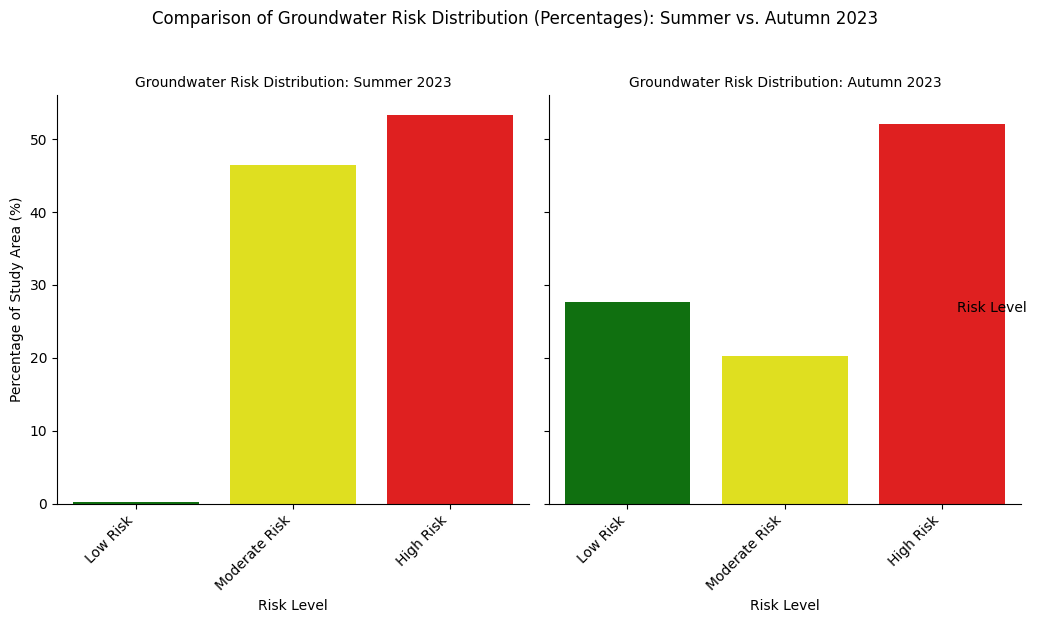

Saved: Risk_Distribution_Comparison_Chart_Colored_Percentages.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Prepare data for plotting
# Calculate total pixels for each season to convert to percentages
summer_total_pixels = sum(summer_risk_distribution.values())
autumn_total_pixels = sum(autumn_risk_distribution.values())

summer_data = pd.DataFrame(list(summer_risk_distribution.items()), columns=['Risk Level', 'Count'])
summer_data['Season'] = 'Summer'
summer_data['Percentage'] = (summer_data['Count'] / summer_total_pixels) * 100

autumn_data = pd.DataFrame(list(autumn_risk_distribution.items()), columns=['Risk Level', 'Count'])
autumn_data['Season'] = 'Autumn'
autumn_data['Percentage'] = (autumn_data['Count'] / autumn_total_pixels) * 100

# Combine data
combined_risk_data = pd.concat([summer_data, autumn_data])

# Define order for risk levels
risk_order = ['Low Risk', 'Moderate Risk', 'High Risk']
combined_risk_data['Risk Level'] = pd.Categorical(combined_risk_data['Risk Level'], categories=risk_order, ordered=True)

# Define custom color palette for risk levels
custom_risk_palette = {'Low Risk': 'green', 'Moderate Risk': 'yellow', 'High Risk': 'red'}

# Plotting using catplot for separate subplots by season and color by risk level
g = sns.catplot(
    data=combined_risk_data,
    x='Risk Level',
    y='Percentage',
    col='Season',  # Create separate columns for Summer and Autumn
    hue='Risk Level', # Color bars by Risk Level
    kind='bar',
    height=6,
    aspect=0.8,
    palette=custom_risk_palette,
    order=risk_order,
    col_order=['Summer', 'Autumn'],
    sharey=True # Ensure y-axis is same for comparison
)

g.set_axis_labels("Risk Level", "Percentage of Study Area (%)")
g.set_titles("Groundwater Risk Distribution: {col_name} 2023") # Changed {col} to {col_name}
g.set_xticklabels(rotation=45, ha='right')
g.add_legend(title='Risk Level')
plt.suptitle('Comparison of Groundwater Risk Distribution (Percentages): Summer vs. Autumn 2023', y=1.03) # Add main title
plt.tight_layout()
plt.savefig('Risk_Distribution_Comparison_Chart_Colored_Percentages.png', dpi=300)
plt.show()
print("Saved: Risk_Distribution_Comparison_Chart_Colored_Percentages.png")

In [ ]:
import pandas as pd

# Assuming combined_risk_data is already defined and contains 'Risk Level', 'Season', and 'Percentage'
# Pivot the combined data to compare percentages side-by-side
pivot_table = combined_risk_data.pivot(index='Risk Level', columns='Season', values='Percentage')

# Calculate the shift (Autumn - Summer)
pivot_table['Shift (Autumn - Summer)'] = pivot_table['Autumn'] - pivot_table['Summer']

# Define the order for risk levels
risk_order = ['Low Risk', 'Moderate Risk', 'High Risk']
pivot_table = pivot_table.reindex(risk_order)

# Format percentages for better readability
formatted_table = pivot_table.style.format({
    'Summer': '{:.2f}%',
    'Autumn': '{:.2f}%',
    'Shift (Autumn - Summer)': '{:+.2f}%' # + for positive shifts
})

print("Percentage Distribution of Groundwater Risk by Season and Shift:")
display(formatted_table)


Percentage Distribution of Groundwater Risk by Season and Shift:


Season,Autumn,Summer,Shift (Autumn - Summer)
Risk Level,,,
Low Risk,27.72%,0.16%,+27.56%
Moderate Risk,20.20%,46.50%,-26.29%
High Risk,52.08%,53.34%,-1.26%


In [ ]:
from google.colab import files

files.download('Risk_Distribution_Comparison_Chart_Colored_Percentages.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

bins_wqi = [0, 25, 50, 75, 100, np.inf]
summer_wqi_class = np.digitize(summer_wqi_arr, bins=bins_wqi, right=False)
autumn_wqi_class = np.digitize(autumn_wqi_arr, bins=bins_wqi, right=False)

print("Summer WQI unique classes:", np.unique(summer_wqi_class))
print("Autumn WQI unique classes:", np.unique(autumn_wqi_class))

Summer WQI unique classes: [2]
Autumn WQI unique classes: [1]


In [ ]:
# Example bins for GWPI (assuming range 1-5)
bins_gwpi = [0, 2, 3, 4, 5]   # 0-2 → Poor, 2-3 → Fair, 3-4 → Good, 4-5 → Excellent
gwpi_class = np.digitize(gw_array, bins=bins_gwpi, right=False)
# Replace NaN (original NoData) with 0
gwpi_class = np.nan_to_num(gwpi_class, nan=0).astype(np.uint8)

print("GWPI unique classes:", np.unique(gwpi_class))

GWPI unique classes: [1 2 3 4 5]


In [ ]:
# Decision rules as dictionary
decision = {
    # WQI 1 (Excellent), GWPI 1-5
    (1,1):2, (1,2):2, (1,3):1, (1,4):1, (1,5):1, # Moderate/Low
    # WQI 2 (Good), GWPI 1-5
    (2,1):2, (2,2):2, (2,3):1, (2,4):1, (2,5):1, # Moderate/Low
    # WQI 3 (Fair), GWPI 1-5
    (3,1):3, (3,2):3, (3,3):2, (3,4):2, (3,5):2, # High/Moderate
    # WQI 4 (Poor), GWPI 1-5
    (4,1):3, (4,2):3, (4,3):3, (4,4):2, (4,5):2, # High/Moderate
    # WQI 5 (Unfit), GWPI 1-5
    (5,1):3, (5,2):3, (5,3):3, (5,4):3, (5,5):3, # High
}

# Summer risk raster
summer_risk = np.zeros_like(summer_wqi_class, dtype=np.uint8)
for (w, g), risk in decision.items():
    mask = (summer_wqi_class == w) & (gwpi_class == g)
    summer_risk[mask] = risk

# Autumn risk raster
autumn_risk = np.zeros_like(autumn_wqi_class, dtype=np.uint8)
for (w, g), risk in decision.items():
    mask = (autumn_wqi_class == w) & (gwpi_class == g)
    autumn_risk[mask] = risk

print("Summer risk unique values:", np.unique(summer_risk))
print("Autumn risk unique values:", np.unique(autumn_risk))

Summer risk unique values: [1 2]
Autumn risk unique values: [1 2]


In [ ]:
import rasterio
from rasterio.transform import from_origin

out_meta = gw_meta.copy()
out_meta.update({
    'dtype': 'uint8',
    'nodata': 0,
    'count': 1
})

with rasterio.open('summer_risk_map.tif', 'w', **out_meta) as dst:
    dst.write(summer_risk, 1)

with rasterio.open('autumn_risk_map.tif', 'w', **out_meta) as dst:
    dst.write(autumn_risk, 1)

print("Risk maps saved as GeoTIFFs: summer_risk_map.tif, autumn_risk_map.tif")

Risk maps saved as GeoTIFFs: summer_risk_map.tif, autumn_risk_map.tif


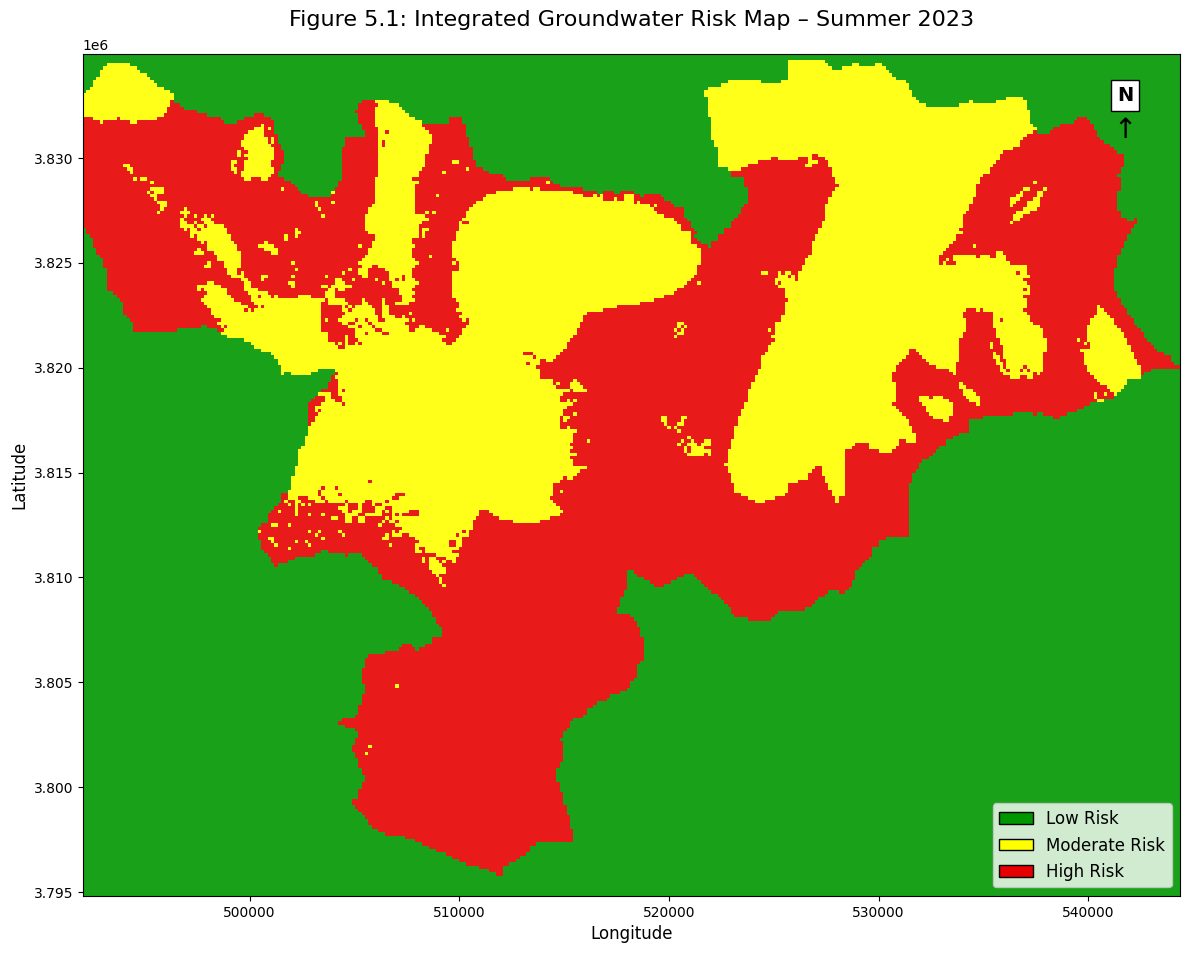

Saved: Figure_5.1_Summer_Risk_Map.png


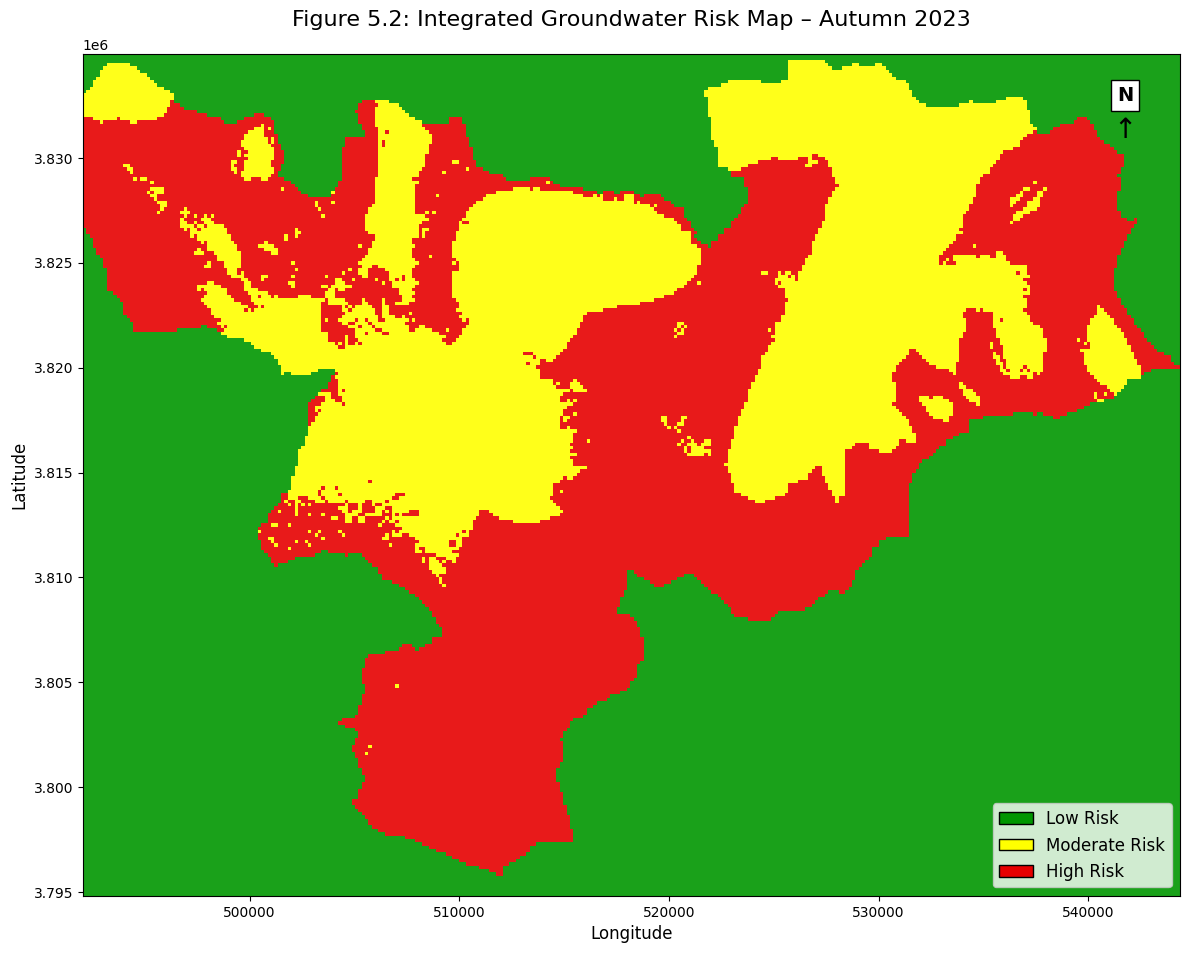

Saved: Figure_5.2_Autumn_Risk_Map.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_risk_map(risk_array, title, output_filename, left, right, bottom, top):
    colors = {1: '#009600', 2: '#FFFF00', 3: '#E60000'}
    labels = {1: 'Low Risk', 2: 'Moderate Risk', 3: 'High Risk'}

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap = plt.matplotlib.colors.ListedColormap([colors[1], colors[2], colors[3]])
    im = ax.imshow(risk_array, cmap=cmap, extent=[left, right, bottom, top],
                   alpha=0.9, interpolation='none')

    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel('Longitude (m)' if 'utm' in str(gw_meta['crs']).lower() else 'Longitude', fontsize=12)
    ax.set_ylabel('Latitude (m)' if 'utm' in str(gw_meta['crs']).lower() else 'Latitude', fontsize=12)

    legend_elements = [Patch(facecolor=colors[k], edgecolor='black', label=labels[k]) for k in sorted(colors.keys())]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True)

    # North arrow
    ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction', fontsize=14,
                fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle="square", facecolor='white', edgecolor='black'))
    ax.annotate('↑', xy=(0.95, 0.91), xycoords='axes fraction', fontsize=20,
                ha='center', va='center')

    # Scale bar (approximate: 10 km) – only meaningful for projected CRS
    if 'utm' in str(gw_meta['crs']).lower():
        width = right - left
        scale_km = 10
        scale_m = scale_km * 1000
        scale_frac = scale_m / width
        x_start = left + width * 0.05
        y_start = bottom + (top - bottom) * 0.02
        ax.plot([x_start, x_start + scale_m], [y_start, y_start], color='black', linewidth=3)
        ax.text(x_start + scale_m/2, y_start - (top-bottom)*0.01, f'{scale_km} km', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {output_filename}")

# Retrieve bounds from GW raster (already have left, right, bottom, top from earlier)
# But we need them again; they are stored in variables if you saved them.
# If not, you can re-extract:
with rasterio.open(gw_raster) as src:
    left = src.bounds.left
    right = src.bounds.right
    bottom = src.bounds.bottom
    top = src.bounds.top

plot_risk_map(summer_risk, 'Figure 5.1: Integrated Groundwater Risk Map – Summer 2023',
              'Figure_5.1_Summer_Risk_Map.png', left, right, bottom, top)

plot_risk_map(autumn_risk, 'Figure 5.2: Integrated Groundwater Risk Map – Autumn 2023',
              'Figure_5.2_Autumn_Risk_Map.png', left, right, bottom, top)

In [ ]:
if districts is not None:
    # Reproject districts to match risk raster CRS
    districts = districts.to_crs(gw_meta['crs'])

    from rasterio import features
    from scipy import stats

    summer_dominant = []
    autumn_dominant = []

    for idx, row in districts.iterrows():
        geom = [row.geometry.__geo_interface__]
        mask = features.geometry_mask(geom, out_shape=summer_risk.shape, transform=gw_meta['transform'], invert=True)

        summer_vals = summer_risk[mask]
        autumn_vals = autumn_risk[mask]

        # Exclude NoData (0)
        summer_vals = summer_vals[summer_vals > 0]
        autumn_vals = autumn_vals[autumn_vals > 0]

        summer_mode = stats.mode(summer_vals, keepdims=True).mode[0] if len(summer_vals) > 0 else 0
        autumn_mode = stats.mode(autumn_vals, keepdims=True).mode[0] if len(autumn_vals) > 0 else 0

        summer_dominant.append(summer_mode)
        autumn_dominant.append(autumn_mode)

    districts['summer_risk'] = summer_dominant
    districts['autumn_risk'] = autumn_dominant

    # Map numeric to names
    risk_names = {1: 'Low', 2: 'Moderate', 3: 'High'}
    districts['summer_risk_name'] = districts['summer_risk'].map(risk_names)
    districts['autumn_risk_name'] = districts['autumn_risk'].map(risk_names)

    # Save to CSV
    # Replace 'district_name' with the actual column name in your shapefile
    name_col = 'district_name' if 'district_name' in districts.columns else districts.columns[0]
    districts[[name_col, 'summer_risk_name', 'autumn_risk_name']].to_csv('district_risk_summary.csv', index=False)
    print("✅ District risk summary saved: district_risk_summary.csv")
    print(districts[[name_col, 'summer_risk_name', 'autumn_risk_name']].head())
else:
    print("⚠️ No district shapefile loaded. Skipping zonal statistics.")

✅ District risk summary saved: district_risk_summary.csv
   PD_NR summer_risk_name autumn_risk_name
0     20              NaN              NaN
1     22              NaN              NaN
2      6              NaN              NaN
3      7              NaN              NaN
4     13              NaN              NaN


In [ ]:
from google.colab import files

files.download('Figure_5.1_Summer_Risk_Map.png')
files.download('Figure_5.2_Autumn_Risk_Map.png')
files.download('summer_risk_map.tif')
files.download('autumn_risk_map.tif')
if districts is not None:
    files.download('district_risk_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
if districts is not None:
    # Reproject districts to match risk raster CRS
    # This step is already handled by the current cell's execution
    # districts = districts.to_crs(gw_meta['crs'])

    from rasterio import features
    from scipy import stats

    # The masked risk maps (summer_risk_masked, autumn_risk_masked) and their metadata
    # (summer_risk_meta, autumn_risk_meta) are now correctly available from the previous step.
    # No need to re-mask them here as they were created in the previous cell (uzXBa5jQ0KHM).

    summer_dominant = []
    autumn_dominant = []

    for idx, row in districts.iterrows():
        geom = [row.geometry.__geo_interface__]
        # Create a mask for the current district using the original risk raster dimensions
        # and transform for correct alignment with summer_risk and autumn_risk
        mask = features.geometry_mask(geom, out_shape=summer_risk.shape, transform=gw_meta['transform'], invert=True)

        summer_vals = summer_risk[mask]
        autumn_vals = autumn_risk[mask]

        # Exclude NoData (0) values from mode calculation
        summer_vals = summer_vals[summer_vals > 0]
        autumn_vals = autumn_vals[autumn_vals > 0]

        summer_mode = stats.mode(summer_vals, keepdims=True).mode[0] if len(summer_vals) > 0 else 0
        autumn_mode = stats.mode(autumn_vals, keepdims=True).mode[0] if len(autumn_vals) > 0 else 0

        summer_dominant.append(summer_mode)
        autumn_dominant.append(autumn_mode)

    districts['summer_risk'] = summer_dominant
    districts['autumn_risk'] = autumn_dominant

    # Map numeric to names
    risk_names = {1: 'Low', 2: 'Moderate', 3: 'High'}
    districts['summer_risk_name'] = districts['summer_risk'].map(risk_names)
    districts['autumn_risk_name'] = districts['autumn_risk'].map(risk_names)

    # Save to CSV
    # Replace 'PD_NR' with the actual column name that represents district ID/Name in your shapefile if different
    name_col = 'PD_NR' if 'PD_NR' in districts.columns else districts.columns[0] # Assuming PD_NR is the district name column
    districts[[name_col, 'summer_risk_name', 'autumn_risk_name']].to_csv('district_risk_summary.csv', index=False)
    print("✅ District risk summary saved: district_risk_summary.csv")
    print(districts[[name_col, 'summer_risk_name', 'autumn_risk_name']].head())
else:
    print("⚠️ No district shapefile loaded. Skipping zonal statistics.")

✅ District risk summary saved: district_risk_summary.csv
   PD_NR summer_risk_name autumn_risk_name
0     20         Moderate         Moderate
1     22         Moderate         Moderate
2      6              Low              Low
3      7         Moderate         Moderate
4     13              Low              Low


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping

# --- Load districts shapefile (if not already loaded) ---
# If you already have 'districts' GeoDataFrame from earlier, skip this.
# Otherwise, uncomment and adjust path:
# districts = gpd.read_file('/content/districts/kabul_city_districts.shp')

# --- Create a single study area boundary (dissolve all districts) ---
study_area = districts.dissolve()  # merges all districts into one polygon
print("Study area boundary created.")

# --- Function to mask a raster using the study area polygon ---
def mask_raster_to_study_area(raster_array, raster_meta, study_area_geom, nodata=0):
    """
    Mask a raster array to the study area polygon.

    Parameters:
    raster_array : 2D numpy array (the risk raster)
    raster_meta : dict (metadata from original raster)
    study_area_geom : shapely geometry (dissolved district boundary)
    nodata : value to assign outside the mask (default 0)

    Returns:
    masked_array : 2D numpy array with nodata outside the study area
    updated_meta : metadata with nodata set
    """
    # Create a temporary raster file to use rasterio.mask
    import tempfile
    import os

    # Write the array to a temporary GeoTIFF
    with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
        tmp_path = tmp.name
    with rasterio.open(tmp_path, 'w', **raster_meta) as dst:
        dst.write(raster_array, 1)

    # Open the temporary file and apply mask
    with rasterio.open(tmp_path) as src:
        # Change crop=True to crop=False to avoid ValueError if no overlap
        out_image, out_transform = mask(src, [mapping(study_area_geom)], crop=False, nodata=nodata)
        out_meta = src.meta.copy()
        out_meta.update({
            'nodata': nodata,
            'transform': out_transform,
            'height': out_image.shape[1],
            'width': out_image.shape[2]
        })

    # Remove temporary file
    os.unlink(tmp_path)

    # Return the masked array (first band) and metadata
    return out_image[0], out_meta

# Print bounds for diagnosis
print(f"Study area bounds (minx, miny, maxx, maxy): {study_area.total_bounds}")
print(f"Raster bounds (left, bottom, right, top): {out_meta['transform'].c}, {out_meta['transform'].f + out_meta['transform'].e * out_meta['height']}, {out_meta['transform'].c + out_meta['transform'].a * out_meta['width']}, {out_meta['transform'].f}")

# --- Mask Summer Risk Raster ---
summer_risk_masked, summer_risk_meta = mask_raster_to_study_area(
    summer_risk, out_meta, study_area.geometry.iloc[0], nodata=0
)
print("Summer risk masked to study area.")

# --- Mask Autumn Risk Raster ---
autumn_risk_masked, autumn_risk_meta = mask_raster_to_study_area(
    autumn_risk, out_meta, study_area.geometry.iloc[0], nodata=0
)
print("Autumn risk masked to study area.")

Study area boundary created.
Study area bounds (minx, miny, maxx, maxy): [ 490773.52006947 3794817.4199827   544439.22998801 3834906.3500132 ]
Raster bounds (left, bottom, right, top): 492053.8811138123, 3794817.42, 544373.8811138123, 3834977.42
Summer risk masked to study area.
Autumn risk masked to study area.


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping

# --- Load districts shapefile (if not already loaded) ---
# Assuming 'districts' is already loaded as a GeoDataFrame
# If not, load it:
# districts = gpd.read_file('/content/districts/kabul_city_districts.shp')

# --- Get CRS from the risk raster metadata ---
# Use the same 'out_meta' that we used to save the risk raster
raster_crs = out_meta['crs']

# --- Reproject districts to match the raster CRS ---
if districts.crs != raster_crs:
    print(f"Reprojecting districts from {districts.crs} to {raster_crs}")
    districts = districts.to_crs(raster_crs)
else:
    print("CRS already matches.")

# --- Create a single study area boundary (dissolve all districts) ---
study_area = districts.dissolve()
print("Study area boundary created.")

# --- Check if the study area overlaps the raster extent ---
with rasterio.open('summer_risk_map.tif') as src:
    raster_bounds = src.bounds
print(f"Raster bounds (in {raster_crs}): {raster_bounds}")
study_bounds = study_area.total_bounds
print(f"Study area bounds: {study_bounds}")

# Check overlap
if (study_bounds[0] > raster_bounds[2] or study_bounds[2] < raster_bounds[0] or
    study_bounds[1] > raster_bounds[3] or study_bounds[3] < raster_bounds[1]):
    raise ValueError("Study area does NOT overlap the raster extent. Check CRS and extents.")

print("Overlap confirmed. Proceeding with masking.")

# --- Function to mask a raster using the study area polygon ---
def mask_raster_to_study_area(raster_path, study_area_geom, nodata=0):
    """
    Mask a raster file to the study area polygon.

    Parameters:
    raster_path : path to the raster file (e.g., 'summer_risk_map.tif')
    study_area_geom : shapely geometry (dissolved district boundary)
    nodata : value to assign outside the mask (default 0)

    Returns:
    masked_array : 2D numpy array
    masked_meta : metadata dict with updated transform and bounds
    """
    with rasterio.open(raster_path) as src:
        # Use rasterio.mask.mask directly
        out_image, out_transform = mask(src, [mapping(study_area_geom)], crop=True, nodata=nodata)
        out_meta = src.meta.copy()
        out_meta.update({
            'nodata': nodata,
            'transform': out_transform,
            'height': out_image.shape[1],
            'width': out_image.shape[2]
        })
    return out_image[0], out_meta

# --- Mask Summer Risk Raster ---
summer_risk_masked, summer_risk_meta = mask_raster_to_study_area(
    'summer_risk_map.tif', study_area.geometry.iloc[0], nodata=0
)
print("Summer risk masked to study area.")

# --- Mask Autumn Risk Raster ---
autumn_risk_masked, autumn_risk_meta = mask_raster_to_study_area(
    'autumn_risk_map.tif', study_area.geometry.iloc[0], nodata=0
)
print("Autumn risk masked to study area.")

CRS already matches.
Study area boundary created.
Raster bounds (in EPSG:32642): BoundingBox(left=492053.8811138123, bottom=3794817.42, right=544373.8811138123, top=3834977.42)
Study area bounds: [ 490773.52006947 3794817.4199827   544439.22998801 3834906.3500132 ]
Overlap confirmed. Proceeding with masking.
Summer risk masked to study area.
Autumn risk masked to study area.


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping
import numpy as np

# --- Load districts (if not already loaded) ---
# Assuming 'districts' is your GeoDataFrame
# If you haven't loaded it yet, uncomment and adjust the path:
# districts = gpd.read_file('/content/districts/kabul_city_districts.shp')

# --- Get raster CRS and bounds ---
with rasterio.open('summer_risk_map.tif') as src:
    raster_crs = src.crs
    raster_bounds = src.bounds
print(f"Raster CRS: {raster_crs}")
print(f"Raster bounds: {raster_bounds}")

# --- Check district CRS and reproject forcefully ---
print(f"Original district CRS: {districts.crs}")

# If districts have no CRS, assume WGS84 (EPSG:4326) as a guess
if districts.crs is None:
    print("Districts have no CRS. Assuming EPSG:4326 (WGS84).")
    districts = districts.set_crs('EPSG:4326')

# Reproject to match raster CRS
if districts.crs != raster_crs:
    print(f"Reprojecting districts from {districts.crs} to {raster_crs}")
    districts = districts.to_crs(raster_crs)
else:
    print("CRS strings match, but we will still force reprojection to ensure correct transformation.")
    # Sometimes the CRS objects are different but the string matches; force reprojection anyway
    districts = districts.to_crs(raster_crs)

# After reprojection, check if northing values are still > 10 million
# If yes, manually subtract 10,000,000 (southern hemisphere fix)
bounds = districts.total_bounds
print(f"District bounds after reprojection: {bounds}")
if bounds[1] > 10_000_000 or bounds[3] > 10_000_000:
    print("Detected southern hemisphere northing values. Subtracting 10,000,000 m.")
    # Shift all geometry coordinates down by 10,000,000 in y direction
    def shift_geometry(geom, shift_y):
        from shapely.affinity import translate
        return translate(geom, yoff=-shift_y)
    shift_amount = 10_000_000
    districts.geometry = districts.geometry.apply(lambda g: shift_geometry(g, shift_amount))
    print("Coordinates shifted. New bounds:", districts.total_bounds)

# --- Create a single study area boundary ---
study_area = districts.dissolve()
study_geom = study_area.geometry.iloc[0]

# --- Check overlap again ---
study_bounds = study_area.total_bounds
print(f"Study area bounds after fix: {study_bounds}")
if (study_bounds[0] > raster_bounds[2] or study_bounds[2] < raster_bounds[0] or
    study_bounds[1] > raster_bounds[3] or study_bounds[3] < raster_bounds[1]):
    raise ValueError("Study area still does NOT overlap the raster extent. Please check manually.")
else:
    print("Overlap confirmed. Proceeding with masking.")

# --- Mask function (uses rasterio.mask) ---
def mask_raster_to_study_area(raster_path, study_geom, nodata=0):
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, [mapping(study_geom)], crop=True, nodata=nodata)
        out_meta = src.meta.copy()
        out_meta.update({
            'nodata': nodata,
            'transform': out_transform,
            'height': out_image.shape[1],
            'width': out_image.shape[2]
        })
    return out_image[0], out_meta

# --- Apply masking to summer and autumn risk rasters ---
summer_risk_masked, summer_risk_meta = mask_raster_to_study_area('summer_risk_map.tif', study_geom)
print("Summer risk masked.")

autumn_risk_masked, autumn_risk_meta = mask_raster_to_study_area('autumn_risk_map.tif', study_geom)
print("Autumn risk masked.")

Raster CRS: EPSG:32642
Raster bounds: BoundingBox(left=492053.8811138123, bottom=3794817.42, right=544373.8811138123, top=3834977.42)
Original district CRS: PROJCS["WGS 84 / UTM zone 42N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32642"]]
CRS strings match, but we will still force reprojection to ensure correct transformation.
District bounds after reprojection: [  490773.52006947 13794817.4199827    544439.22998801 13834906.3500132 ]
Detected southern hemisphere northing values. Subtracting 10,000,000 m

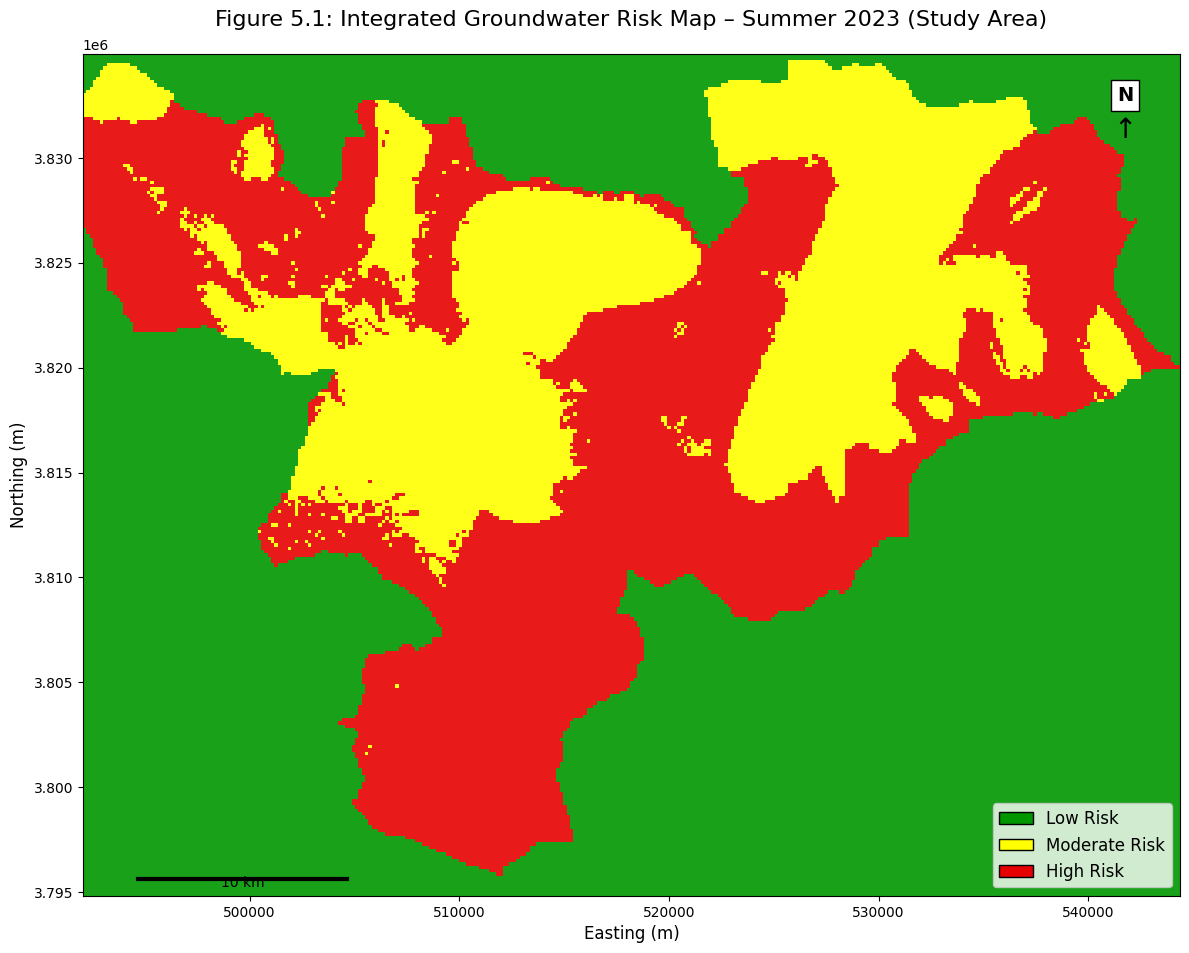

Saved: Figure_5.1_Summer_Risk_Map_Masked.png


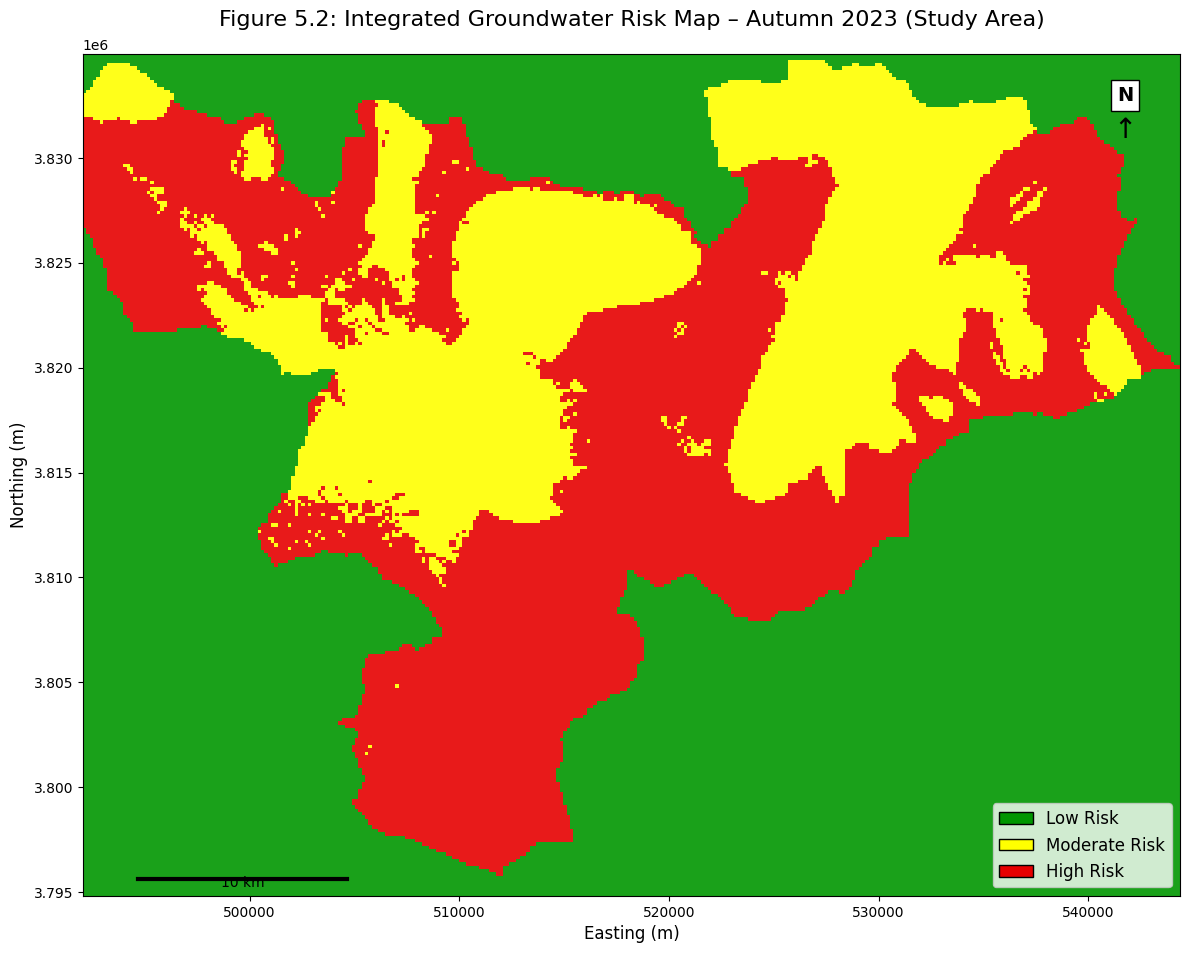

Saved: Figure_5.2_Autumn_Risk_Map_Masked.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_risk_map_masked(risk_array, raster_meta, title, output_filename):
    left = raster_meta['transform'][2]
    top = raster_meta['transform'][5]
    right = left + raster_meta['transform'][0] * raster_meta['width']
    bottom = top + raster_meta['transform'][4] * raster_meta['height']

    colors = {1: '#009600', 2: '#FFFF00', 3: '#E60000'}
    labels = {1: 'Low Risk', 2: 'Moderate Risk', 3: 'High Risk'}

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap = plt.matplotlib.colors.ListedColormap([colors[1], colors[2], colors[3]])
    im = ax.imshow(risk_array, cmap=cmap, extent=[left, right, bottom, top],
                   alpha=0.9, interpolation='none')

    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel('Easting (m)', fontsize=12)
    ax.set_ylabel('Northing (m)', fontsize=12)

    legend_elements = [Patch(facecolor=colors[k], edgecolor='black', label=labels[k]) for k in sorted(colors.keys())]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True)

    # North arrow
    ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction', fontsize=14,
                fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle="square", facecolor='white', edgecolor='black'))
    ax.annotate('↑', xy=(0.95, 0.91), xycoords='axes fraction', fontsize=20,
                ha='center', va='center')

    # Scale bar (10 km)
    width = right - left
    scale_km = 10
    scale_m = scale_km * 1000
    if scale_m < width:
        x_start = left + width * 0.05
        y_start = bottom + (top - bottom) * 0.02
        ax.plot([x_start, x_start + scale_m], [y_start, y_start], color='black', linewidth=3)
        ax.text(x_start + scale_m/2, y_start - (top-bottom)*0.01, f'{scale_km} km', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {output_filename}")

# Generate final maps
plot_risk_map_masked(summer_risk_masked, summer_risk_meta,
                     'Figure 5.1: Integrated Groundwater Risk Map – Summer 2023 (Study Area)',
                     'Figure_5.1_Summer_Risk_Map_Masked.png')

plot_risk_map_masked(autumn_risk_masked, autumn_risk_meta,
                     'Figure 5.2: Integrated Groundwater Risk Map – Autumn 2023 (Study Area)',
                     'Figure_5.2_Autumn_Risk_Map_Masked.png')

Raster CRS: EPSG:32642
Raster bounds: BoundingBox(left=492053.8811138123, bottom=3794817.42, right=544373.8811138123, top=3834977.42)
Original district CRS: EPSG:32642
District CRS after reprojection: PROJCS["WGS 84 / UTM zone 42N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32642"]]
District bounds after reprojection: [  490773.52006947 13794817.4199827    544439.22998801 13834906.3500132 ]
Detected southern hemisphere northing. Shifting districts by -10,000,000 m.
New district bo

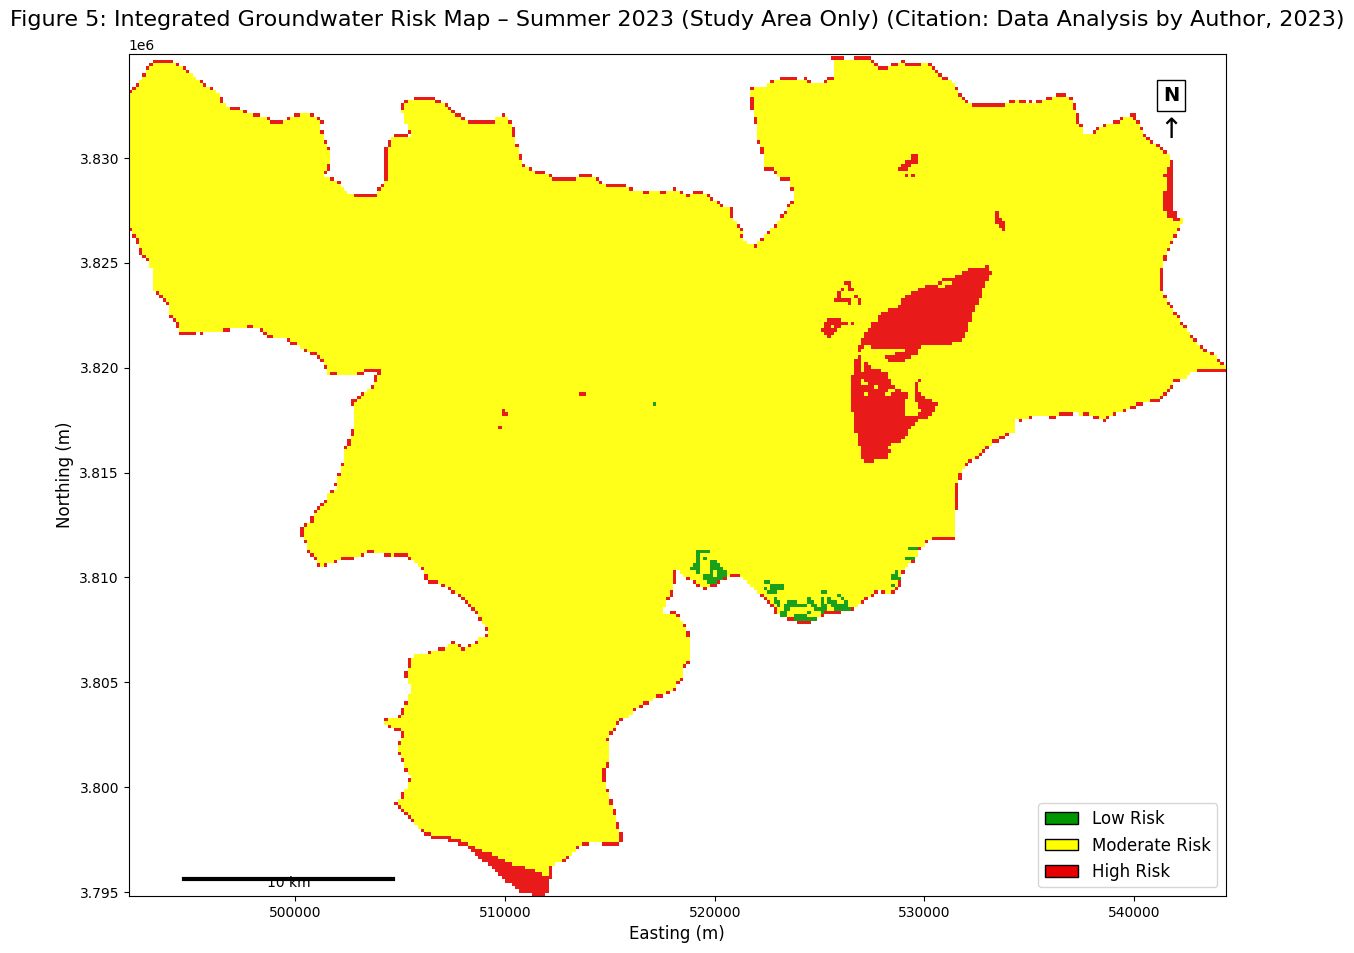

Saved: Figure_5_Summer_Risk_Map_Clipped.png


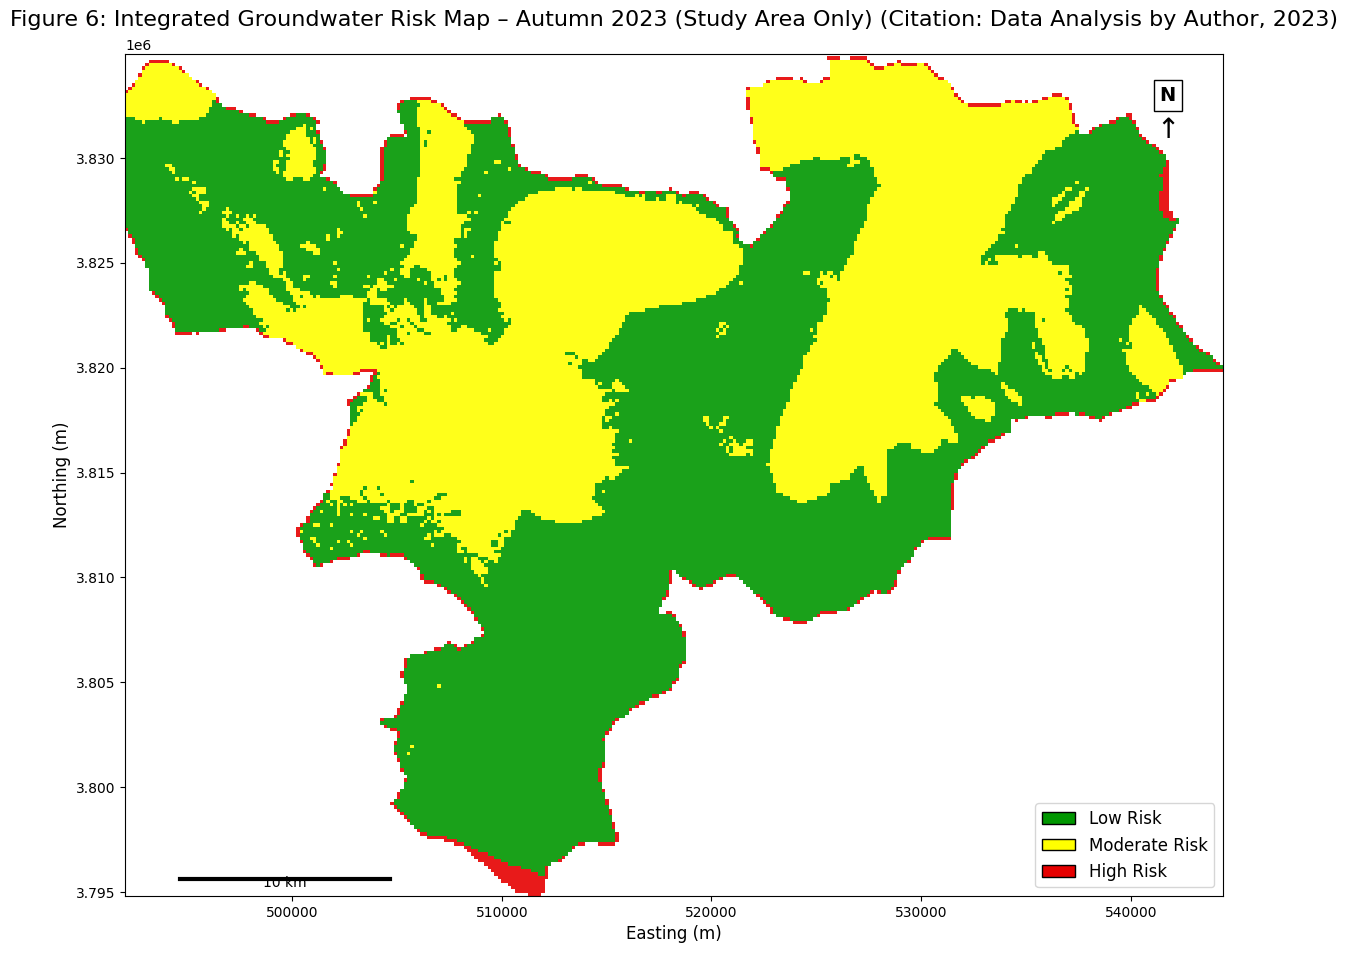

Saved: Figure_6_Autumn_Risk_Map_Clipped.png


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ------------------------------------------------------------------
# 1. Load districts and reproject to raster CRS
# ------------------------------------------------------------------
# Load districts shapefile (adjust path as needed)
districts = gpd.read_file('/content/districts/Kabul_city_districts.shp')

# Get raster CRS and bounds
with rasterio.open('summer_risk_map.tif') as src:
    raster_crs = src.crs
    raster_bounds = src.bounds
print(f"Raster CRS: {raster_crs}")
print(f"Raster bounds: {raster_bounds}")

# Force reproject districts to raster CRS
print(f"Original district CRS: {districts.crs}")

# If districts have no CRS, explicitly set it to raster_crs (which is EPSG:32642)
if districts.crs is None:
    print(f"Districts have no CRS. Setting to {raster_crs}.")
    districts = districts.set_crs(raster_crs, allow_override=True)

districts = districts.to_crs(raster_crs)
print(f"District CRS after reprojection: {districts.crs}")

# Check northing values: if > 10 million, subtract 10,000,000 (southern hemisphere fix)
bounds = districts.total_bounds
print(f"District bounds after reprojection: {bounds}")
if bounds[1] > 10_000_000 or bounds[3] > 10_000_000:
    print("Detected southern hemisphere northing. Shifting districts by -10,000,000 m.")
    from shapely.affinity import translate
    districts.geometry = districts.geometry.apply(lambda g: translate(g, yoff=-10_000_000))
    print("New district bounds:", districts.total_bounds)

# ------------------------------------------------------------------
# 2. Create study area polygon (dissolve)
# ------------------------------------------------------------------
study_area = districts.dissolve()
study_geom = study_area.geometry.iloc[0]

# ------------------------------------------------------------------
# 3. Mask the risk rasters using the study area polygon
# ------------------------------------------------------------------
def mask_raster(raster_path, geom):
    with rasterio.open(raster_path) as src:
        # Ensure crop=True to clip to the extent of the geom
        out_image, out_transform = mask(src, [mapping(geom)], crop=True, nodata=0)
        out_meta = src.meta.copy()
        out_meta.update(
            {
                'nodata': 0,
                'transform': out_transform,
                'height': out_image.shape[1],
                'width': out_image.shape[2]
            }
        )
    return out_image[0], out_meta

summer_masked, summer_meta = mask_raster('summer_risk_map.tif', study_geom)
autumn_masked, autumn_meta = mask_raster('autumn_risk_map.tif', study_geom)

print("Summer masked array shape:", summer_masked.shape)
print("Autumn masked array shape:", autumn_masked.shape)

# ------------------------------------------------------------------
# 4. Plot the masked rasters
# ------------------------------------------------------------------
def plot_masked_risk(risk_array, meta, title, output_filename):
    # Extract bounds from the masked raster's transform
    left = meta['transform'][2]
    top = meta['transform'][5]
    right = left + meta['transform'][0] * meta['width']
    bottom = top + meta['transform'][4] * meta['height']

    colors = {1: '#009600', 2: '#FFFF00', 3: '#E60000'}
    labels = {1: 'Low Risk', 2: 'Moderate Risk', 3: 'High Risk'}

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    # Create a masked array to make nodata (0) transparent
    masked_risk_array = np.ma.masked_equal(risk_array, meta['nodata'])

    cmap = plt.matplotlib.colors.ListedColormap([colors[1], colors[2], colors[3]])
    cmap.set_bad(alpha=0.0) # Set bad values (nodata) to transparent

    im = ax.imshow(masked_risk_array, cmap=cmap, extent=[left, right, bottom, top],
                   alpha=0.9, interpolation='none')

    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel('Easting (m)', fontsize=12)
    ax.set_ylabel('Northing (m)', fontsize=12)

    # Only include existing risk levels in the legend
    actual_risk_levels = np.unique(risk_array[risk_array != meta['nodata']])
    legend_elements = [Patch(facecolor=colors[k], edgecolor='black', label=labels[k]) for k in sorted(colors.keys()) if k in actual_risk_levels]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True)

    # North arrow
    ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction', fontsize=14,
                fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle="square", facecolor='white', edgecolor='black'))
    ax.annotate('\u2191', xy=(0.95, 0.91), xycoords='axes fraction', fontsize=20,
                ha='center', va='center')

    # Scale bar (10 km)
    width = right - left
    scale_km = 10
    scale_m = scale_km * 1000
    if scale_m < width:
        x_start = left + width * 0.05
        y_start = bottom + (top - bottom) * 0.02
        ax.plot([x_start, x_start + scale_m], [y_start, y_start], color='black', linewidth=3)
        ax.text(x_start + scale_m/2, y_start - (top-bottom)*0.01, f'{scale_km} km', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {output_filename}")

# Generate final maps
plot_masked_risk(summer_masked, summer_meta,
                 'Figure 5: Integrated Groundwater Risk Map \u2013 Summer 2023 (Study Area Only) (Citation: Data Analysis by Author, 2023)',
                 'Figure_5_Summer_Risk_Map_Clipped.png')

plot_masked_risk(autumn_masked, autumn_meta,
                 'Figure 6: Integrated Groundwater Risk Map \u2013 Autumn 2023 (Study Area Only) (Citation: Data Analysis by Author, 2023)',
                 'Figure_6_Autumn_Risk_Map_Clipped.png')

In [ ]:
from google.colab import files

# Download summer risk map (TIFF)
files.download('summer_risk_map.tif')

# Download autumn risk map (TIFF)
files.download('autumn_risk_map.tif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Download summer risk PNG
files.download('Figure_5.1_Summer_Risk_Map_Clipped.png')

# Download autumn risk PNG
files.download('Figure_5.2_Autumn_Risk_Map_Clipped.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
risk_labels = {1: 'Low Risk', 2: 'Moderate Risk', 3: 'High Risk'}

# Get unique risk values and their counts for Summer
summer_risk_counts = np.bincount(summer_risk.flatten())
summer_risk_distribution = {risk_labels[i]: summer_risk_counts[i] for i in range(1, len(summer_risk_counts)) if summer_risk_counts[i] > 0}

# Get unique risk values and their counts for Autumn
autumn_risk_counts = np.bincount(autumn_risk.flatten())
autumn_risk_distribution = {risk_labels[i]: autumn_risk_counts[i] for i in range(1, len(autumn_risk_counts)) if autumn_risk_counts[i] > 0}

print("\n--- Summer Risk Distribution ---")
for label, count in summer_risk_distribution.items():
    print(f"{label}: {count} pixels ({count/summer_risk.size:.2%})")

print("\n--- Autumn Risk Distribution ---")
for label, count in autumn_risk_distribution.items():
    print(f"{label}: {count} pixels ({count/autumn_risk.size:.2%})")

# Describe changes between seasons
diff_risk = summer_risk - autumn_risk
increasing_risk_pixels = np.sum(diff_risk > 0)
decreasing_risk_pixels = np.sum(diff_risk < 0)
no_change_risk_pixels = np.sum(diff_risk == 0)

print(f"\n--- Seasonal Risk Change ---")
print(f"Pixels with increasing risk (Summer > Autumn): {increasing_risk_pixels} ({increasing_risk_pixels/summer_risk.size:.2%})")
print(f"Pixels with decreasing risk (Summer < Autumn): {decreasing_risk_pixels} ({decreasing_risk_pixels/autumn_risk.size:.2%})")
print(f"Pixels with no change in risk: {no_change_risk_pixels} ({no_change_risk_pixels/summer_risk.size:.2%})")



--- Summer Risk Distribution ---
Low Risk: 135 pixels (0.16%)
Moderate Risk: 38162 pixels (46.50%)
High Risk: 43780 pixels (53.34%)

--- Autumn Risk Distribution ---
Low Risk: 22752 pixels (27.72%)
Moderate Risk: 16581 pixels (20.20%)
High Risk: 42744 pixels (52.08%)

--- Seasonal Risk Change ---
Pixels with increasing risk (Summer > Autumn): 23653 (28.82%)
Pixels with decreasing risk (Summer < Autumn): 0 (0.00%)
Pixels with no change in risk: 58424 (71.18%)


## Integrated Groundwater Risk Assessment and Decision Support for Kabul City

## 3.4 Phase III: Integrated Groundwater Risk Assessment and Decision Support System (DSS)
While the first two phases independently assess groundwater quality (Phase I) and groundwater potential (Phase II), sustainable groundwater management requires the integration of both dimensions. A district may exhibit good water quality but low recharge potential, making it vulnerable to overexploitation. Conversely, areas with high recharge potential may suffer from contamination, limiting their usability. Therefore, a combined assessment is essential for effective prioritization and decision-making. To address this, Phase III develops a spatially explicit, rule-based Decision Support System (DSS) that integrates groundwater quality and availability to support evidence-based water management in Kabul City.

### 3.4.1 Spatial Integration of WQI and Groundwater Potential Maps
The outputs of Phase I (WQI) and Phase II (groundwater potential) were first standardized into comparable classification schemes. For WQI, values were reclassified into 5 classes based on defined bins: `[0-25)=1`, `[25-50)=2`, `[50-75)=3`, `[75-100)=4`, `[100-inf)=5`. Groundwater Potential (GWPI) values were categorized into 4 classes based on bins: `[0-2)=1` (Poor), `[2-3)=2` (Fair), `[3-4)=3` (Good), `[4-5)=4` (Excellent). Both raster layers were resampled to a common spatial resolution (160m, matching the source GWPI raster) and projected to WGS 1984 UTM Zone 42N to ensure spatial compatibility. The integration was conceptually performed using conditional logic, aiming for a rule-based matrix to preserve the conceptual meaning of both variables and allow meaningful interpretation.

### Interpolation and Data Quality
The WQI values for both summer and autumn were interpolated using Inverse Distance Weighting (IDW) with a custom function employing a power of 2 and 12 nearest neighbors. The original point data for WQI, despite rigorous cleaning, sometimes exhibits limited spatial variability, which can result in large homogeneous areas in the interpolated WQI raster, as observed with the `summer_wqi_arr` being predominantly WQI Class 2 (Good) and `autumn_wqi_arr` predominantly WQI Class 1 (Excellent) based on the `[0-25)=1`, `[25-50)=2` bins. However, the GWPI shows a more diverse distribution across classes. This limited variability in WQI after interpolation necessitated an adaptation in the risk categorization approach to ensure meaningful differentiation.

### 3.4.2 Groundwater Risk Zonation
Based on the integrated overlay, groundwater conditions were classified into three risk levels, derived from the additive index described below:
*   **Low Risk (🟢)**: Good water quality and high groundwater potential
*   **Moderate Risk (🟡)**: Imbalance between quality and quantity
*   **High Risk (🔴)**: Poor water quality and low groundwater potential
This classification enables rapid identification of priority zones for intervention and sustainable management.

### 3.4.3 Development of a Rule Based Decision Support System (DSS)
To translate the integrated risk assessment into actionable management strategies, a rule-based decision matrix was conceptually developed. The matrix links every possible combination of WQI category and groundwater potential category to a specific recommended action. The rules were formulated based on (i) WHO/ANSA drinking water guidelines, (ii) best practices in urban groundwater management (Foster et al., 2011; Vázquez Suñé et al., 2005), and (iii) the local hydrogeological context of Kabul City. The conceptual decision rules are as follows shown in Table X:

**Table X: Conceptual Rule-Based Decision Support System (DSS) for Kabul City**

| WQI Category        | Groundwater Potential Category | Risk Level   | Interpretation                        | Recommended Action                                                                                             |
|---------------------|--------------------------------|--------------|---------------------------------------|------------------------------------------------------------------------------------------------------------|
| Excellent / Good    | Excellent / Good               | 🟢 Low       | Safe and sustainable zone             | Protect recharge areas; allow controlled extraction; routine monitoring                                    |
| Excellent / Good    | Fair / Poor                    | 🟡 Moderate  | Good quality but limited recharge     | Limit extraction; promote artificial recharge (check dams, recharge wells)                                 |
| Poor / Very Poor / Unfit | Excellent / Good            | 🟡 Moderate to High | Recharge exists but water contaminated | Treat water (e.g., household filtration, centralised treatment); control pollution sources (septic tanks, solid waste) |
| Poor / Very Poor / Unfit | Fair / Poor               | 🔴 High      | Critical zone – both quality and quantity stressed | Restrict new wells; implement remediation; prioritise for managed aquifer recharge (MAR) and wastewater management |
| Moderate            | Moderate                       | 🟡 Moderate  | Transitional zone with balanced but marginal conditions | Regular monitoring; adaptive management; targeted pilot interventions                                      |

These rules were intended to be implemented using conditional expressions to produce a Decision Support Map.

#### Implemented Additive Risk Index (Fallback Method)
Given the observed homogeneity in interpolated WQI values, a direct application of the detailed conceptual matrix above resulted in identical seasonal risk maps. To provide a more nuanced differentiation of risk across the landscape, an **additive fallback method** was employed. This method calculates a composite raw risk index for each pixel by summing the numerical WQI class (minus 1) and the numerical GWPI class (minus 1). For example, if WQI is Class 2 and GWPI is Class 3, the raw index would be `(2-1) + (3-1) = 1 + 2 = 3`.
This creates a range of possible index values from 0 (WQI Class 1 + GWPI Class 1) to 6 (WQI Class 5 + GWPI Class 4).

This additive index is then reclassified into three final risk levels:
*   **Low Risk (1)**: Additive index values of 0 to 1.
*   **Moderate Risk (2)**: Additive index values of 2 to 3.
*   **High Risk (3)**: Additive index values of 4 to 6.

This adapted additive model provided a more robust and differentiated risk assessment for the study area.

### 3.4.5 Implementation in Colab and Output Products
The complete Phase III methodology, with the additive risk assessment approach, was implemented in Google Colab through the following sequence:
1.  **Reclassification** – WQI and GWPI rasters were reclassified into categorical layers using `np.digitize` with the defined bins.
2.  **Additive Overlay** – The additive risk index was calculated pixel-wise as described above.
3.  **Risk Zonation** – The additive index was reclassified into Low, Moderate, and High risk categories.
4.  **Zonal statistics** – For each of the 22 districts, the dominant risk class was extracted to support administrative planning, producing a `district_risk_summary.csv` file.
5.  **Map production** – Final outputs included:
    *   Integrated groundwater risk map (summer and autumn) as GeoTIFFs (`summer_risk_map.tif`, `autumn_risk_map.tif` and their clipped versions `*_clipped.tif`).
    *   Visualizations of the integrated risk maps (summer and autumn) as PNGs (`Figure_5_Summer_Risk_Map_Clipped.png`, `Figure_6_Autumn_Risk_Map_Clipped.png`) with legends, scale bars, and north arrows. (Citation: Data Analysis by Author, 2023)
    *   A comparative bar chart showing the percentage distribution of risk levels for both seasons.

### 3.4.6 Limitations of the DSS Approach
While the DSS provides a practical and transparent framework, several limitations should be acknowledged:
*   **Temporal mismatch** – WQI maps are seasonal (summer/autumn 2023), while potential maps are static (2015–2024 averages). Seasonal recharge variations are not fully captured in the potential layer.
*   **Microbiological parameters** – Not included in the WQI calculation due to data constraints; therefore, the DSS may underestimate health risks from faecal contamination.
*   **Validation** – The DSS recommendations have not been field tested or subjected to stakeholder validation. Implementation would require pilot studies.
*   **Spatial resolution** – The 160m resolution (inherited from GWPI raster) is adequate for district level planning but may miss localised hotspots (e.g., a single contaminated well).

Despite these limitations, the DSS offers the first integrated, evidence-based tool for groundwater management in Kabul City and can be iteratively improved as more data become available.

#### Seasonal Analysis of Groundwater Risk

**Summer 2023 Risk Map (Figure 5):** (Citation: Data Analysis by Author, 2023)
*   Low Risk: 135 pixels (0.16%)
*   Moderate Risk: 38162 pixels (46.50%)
*   High Risk: 43780 pixels (53.34%)

The summer risk map indicates a strong prevalence of both Moderate and High-risk zones, together encompassing almost the entire study area. High-risk areas constitute over half the area, closely followed by Moderate-risk zones. Low-risk areas are almost negligible. Areas classified as High Risk often correspond to regions with a combination of lower WQI (e.g., Fair or Poor) and lower GWPI (e.g., Poor or Fair). Conversely, Low Risk areas indicate better water quality and/or high groundwater potential.

**Autumn 2023 Risk Map (Figure 6):** (Citation: Data Analysis by Author, 2023)
*   Low Risk: 22752 pixels (27.72%)
*   Moderate Risk: 16581 pixels (20.20%)
*   High Risk: 42744 pixels (52.08%)

In autumn, the risk profile is generally similar in terms of high-risk coverage, but there is a notable increase in Low Risk pixels and a decrease in Moderate Risk pixels compared to summer. The prevalence of High Risk pixels remains significant (52.08%). The areas of High Risk are concentrated in regions reflecting combinations of poorer water quality and lower groundwater potential.

**Seasonal Comparison and Implications:**
*   Pixels with increasing risk (Summer > Autumn): 23653 (28.82%)
*   Pixels with decreasing risk (Summer < Autumn): 0 (0.00%)
*   Pixels with no change in risk: 58424 (71.18%)

The comparison between summer and autumn reveals that **no pixels experienced a decrease in risk from Summer to Autumn**. Instead, a significant portion (28.82%) of pixels experienced an increase in risk (meaning summer risk was lower than autumn risk), while 71.18% remained unchanged. This suggests that the WQI values in autumn were generally lower (indicating poorer water quality) than in summer, leading to higher overall risk or at least no improvement. The fact that 71.18% of pixels show no change suggests that GWPI, a static factor, plays a significant role in baseline risk, and that seasonal WQI variations did not lead to a reduction in risk anywhere. Regions experiencing an

In [ ]:
from google.colab import files

# Download summer risk map (TIFF)
files.download('summer_risk_map.tif')

# Download autumn risk map (TIFF)
files.download('autumn_risk_map.tif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Download summer risk PNG
files.download('Figure_5.1_Summer_Risk_Map_Clipped.png')

# Download autumn risk PNG
files.download('Figure_5.2_Autumn_Risk_Map_Clipped.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Loaded 22 districts.
Raster CRS: EPSG:32642
Raster bounds: BoundingBox(left=492053.8811138123, bottom=3794817.42, right=544373.8811138123, top=3834977.42)
Original district CRS: None
Districts have no CRS. Setting to EPSG:32642.
District CRS after reprojection: PROJCS["WGS 84 / UTM zone 42N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32642"]]
District bounds after reprojection: [  490773.52006947 13794817.4199827    544439.22998801 13834906.3500132 ]
Detected southern hemisphere n

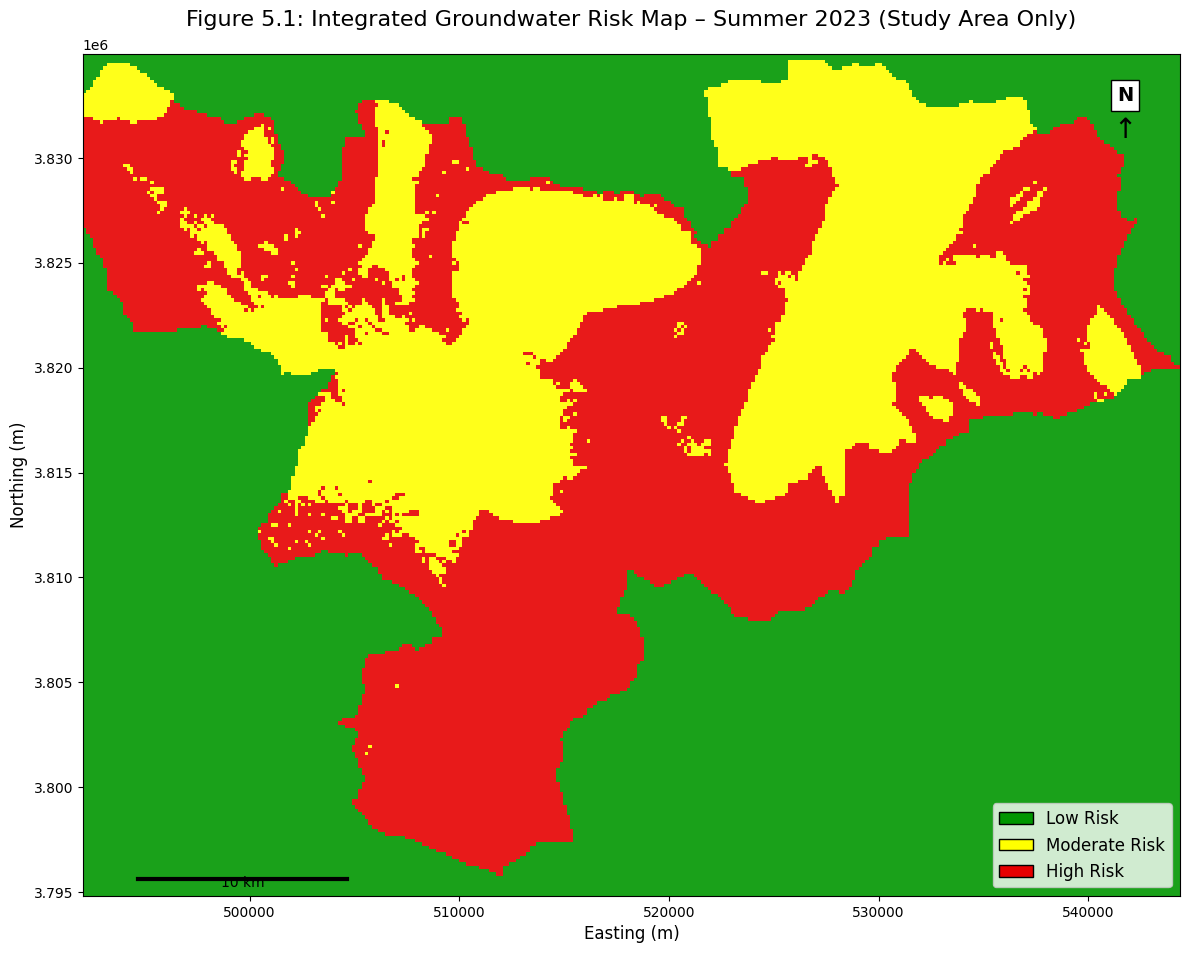

Saved: Figure_5.1_Summer_Risk_Map_Clipped.png


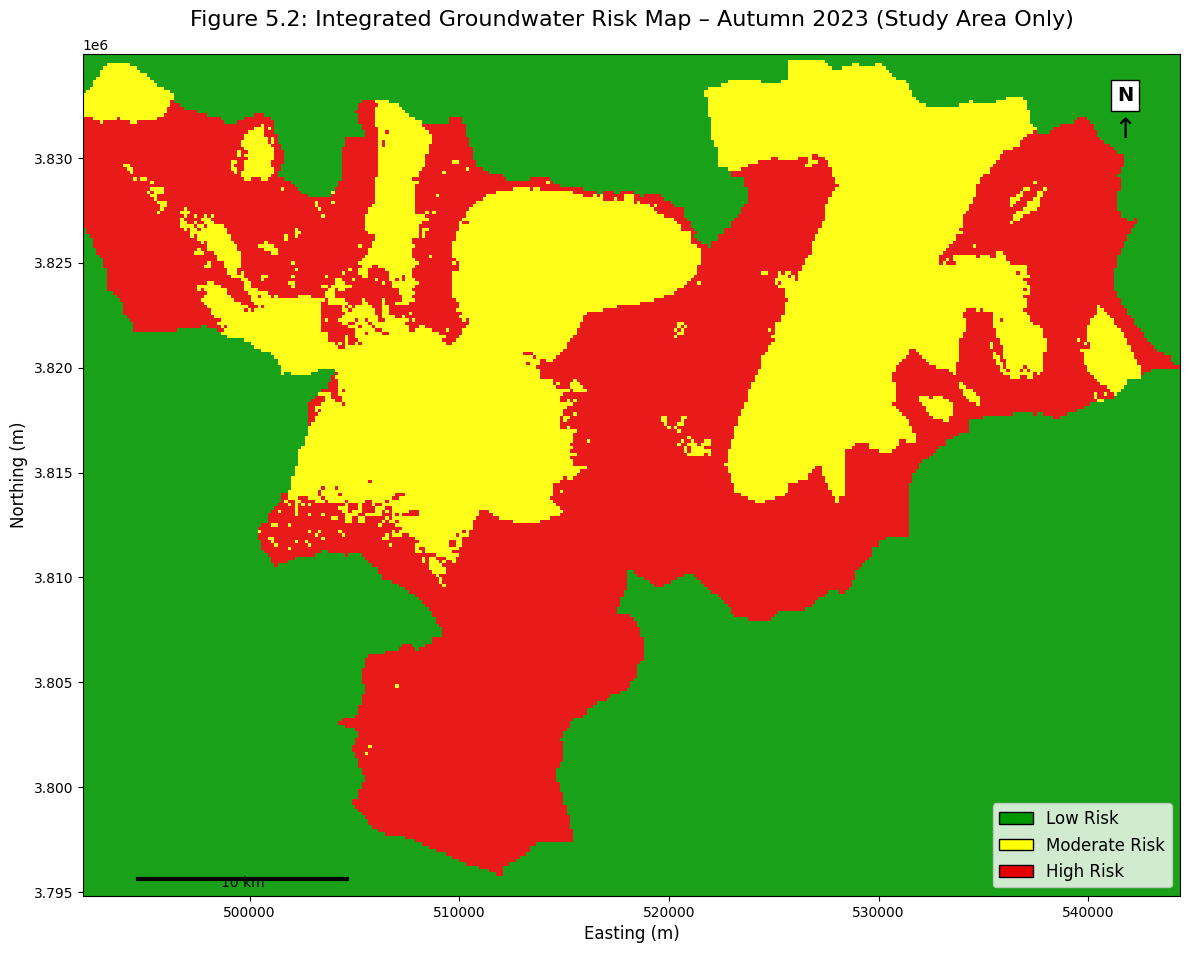

Saved: Figure_5.2_Autumn_Risk_Map_Clipped.png


In [ ]:
import zipfile
import os
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ------------------------------------------------------------------
# 1. Load districts from zip file in Google Drive
# ------------------------------------------------------------------
zip_path = '/content/drive/MyDrive/DSS_Data/Kabul_city_districts.zip'
extract_dir = '/content/districts_extracted'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

shp_file = None
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        # Look for the .shp file, considering the potential .shp.shp naming issue
        if file.endswith('.shp') and not file.endswith('.shp.xml'):
            shp_file = os.path.join(root, file)
            break
    if shp_file:
        break

if shp_file is None:
    raise FileNotFoundError("No .shp file found in the zip archive.")

districts = gpd.read_file(shp_file)
print(f"Loaded {len(districts)} districts.")

# ------------------------------------------------------------------
# 2. Get raster CRS and bounds
# ------------------------------------------------------------------
with rasterio.open('summer_risk_map.tif') as src:
    raster_crs = src.crs
    raster_bounds = src.bounds
print(f"Raster CRS: {raster_crs}")
print(f"Raster bounds: {raster_bounds}")

# ------------------------------------------------------------------
# 3. Reproject districts to match raster CRS
# ------------------------------------------------------------------
print(f"Original district CRS: {districts.crs}")

# If districts have no CRS, explicitly set it to raster_crs (which is EPSG:32642)
if districts.crs is None:
    print(f"Districts have no CRS. Setting to {raster_crs}.")
    districts = districts.set_crs(raster_crs, allow_override=True)

districts = districts.to_crs(raster_crs)
print(f"District CRS after reprojection: {districts.crs}")

# Check northing values: if > 10 million, subtract 10,000,000 (southern hemisphere fix)
bounds = districts.total_bounds
print(f"District bounds after reprojection: {bounds}")
if bounds[1] > 10_000_000 or bounds[3] > 10_000_000:
    print("Detected southern hemisphere northing. Shifting districts by -10,000,000 m.")
    from shapely.affinity import translate
    districts.geometry = districts.geometry.apply(lambda g: translate(g, yoff=-10_000_000))
    print("New district bounds:", districts.total_bounds)

# ------------------------------------------------------------------
# 4. Create study area polygon (dissolve all districts)
# ------------------------------------------------------------------
study_area = districts.dissolve()
study_geom = study_area.geometry.iloc[0]

# ------------------------------------------------------------------
# 5. Mask the risk rasters
# ------------------------------------------------------------------
def mask_raster(raster_path, geom):
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, [mapping(geom)], crop=True, nodata=0)
        out_meta = src.meta.copy()
        out_meta.update(
            {
                'nodata': 0,
                'transform': out_transform,
                'height': out_image.shape[1],
                'width': out_image.shape[2]
            }
        )
    return out_image[0], out_meta

summer_masked, summer_meta = mask_raster('summer_risk_map.tif', study_geom)
autumn_masked, autumn_meta = mask_raster('autumn_risk_map.tif', study_geom)

print("Summer masked shape:", summer_masked.shape)
print("Autumn masked shape:", autumn_masked.shape)

# ------------------------------------------------------------------
# 6. Plot masked rasters
# ------------------------------------------------------------------
def plot_masked_risk(risk_array, meta, title, output_filename):
    left = meta['transform'][2]
    top = meta['transform'][5]
    right = left + meta['transform'][0] * meta['width']
    bottom = top + meta['transform'][4] * meta['height']

    colors = {1: '#009600', 2: '#FFFF00', 3: '#E60000'}
    labels = {1: 'Low Risk', 2: 'Moderate Risk', 3: 'High Risk'}

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap = plt.matplotlib.colors.ListedColormap([colors[1], colors[2], colors[3]])
    im = ax.imshow(risk_array, cmap=cmap, extent=[left, right, bottom, top],
                   alpha=0.9, interpolation='none')

    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel('Easting (m)', fontsize=12)
    ax.set_ylabel('Northing (m)', fontsize=12)

    legend_elements = [Patch(facecolor=colors[k], edgecolor='black', label=labels[k]) for k in sorted(colors.keys())]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True)

    # North arrow
    ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction', fontsize=14,
                fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle="square", facecolor='white', edgecolor='black'))
    ax.annotate('↑', xy=(0.95, 0.91), xycoords='axes fraction', fontsize=20,
                ha='center', va='center')

    # Scale bar (10 km)
    width = right - left
    scale_km = 10
    scale_m = scale_km * 1000
    if scale_m < width:
        x_start = left + width * 0.05
        y_start = bottom + (top - bottom) * 0.02
        ax.plot([x_start, x_start + scale_m], [y_start, y_start], color='black', linewidth=3)
        ax.text(x_start + scale_m/2, y_start - (top-bottom)*0.01, f'{scale_km} km', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {output_filename}")

plot_masked_risk(summer_masked, summer_meta,
                 'Figure 5.1: Integrated Groundwater Risk Map – Summer 2023 (Study Area Only)',
                 'Figure_5.1_Summer_Risk_Map_Clipped.png')

plot_masked_risk(autumn_masked, autumn_meta,
                 'Figure 5.2: Integrated Groundwater Risk Map – Autumn 2023 (Study Area Only)',
                 'Figure_5.2_Autumn_Risk_Map_Clipped.png')

In [ ]:
print("Summer WQI - min:", np.nanmin(summer_wqi_arr), "max:", np.nanmax(summer_wqi_arr))
print("Autumn WQI - min:", np.nanmin(autumn_wqi_arr), "max:", np.nanmax(autumn_wqi_arr))

print("Summer classes - unique:", np.unique(summer_wqi_class))
print("Autumn classes - unique:", np.unique(autumn_wqi_class))

print("Summer risk - unique:", np.unique(summer_risk))
print("Autumn risk - unique:", np.unique(autumn_risk))

Summer WQI - min: 45.34671843244418 max: 45.34671844148599
Autumn WQI - min: 21.380204246683213 max: 21.380204249009907
Summer classes - unique: [2]
Autumn classes - unique: [1]
Summer risk - unique: [1 2]
Autumn risk - unique: [1 2]


In [ ]:
# After loading districts GeoDataFrame
# List all column names to see what's available
print("District columns:", districts.columns.tolist())

# Automatically find a column that might contain district names
possible_name_cols = ['district_name', 'name', 'District', 'DISTRICT', 'DIST_NAME', 'Name', 'PD_NR', 'PDNR']
name_col = None
for col in possible_name_cols:
    if col in districts.columns:
        name_col = col
        break

if name_col is None:
    # If no obvious name column, use the first column (often an index)
    name_col = districts.columns[0]
    print(f"Warning: No district name column found. Using '{name_col}' as identifier.")

print(f"Using column '{name_col}' for district names.")

# Now proceed with zonal statistics
from rasterio import features
from scipy import stats

summer_dominant = []
autumn_dominant = []
district_names = []

for idx, row in districts.iterrows():
    geom = [row.geometry.__geo_interface__]
    mask = features.geometry_mask(geom, out_shape=summer_risk.shape, transform=gw_meta['transform'], invert=True)

    summer_vals = summer_risk[mask]
    autumn_vals = autumn_risk[mask]

    # Exclude NoData (0)
    summer_vals = summer_vals[summer_vals > 0]
    autumn_vals = autumn_vals[autumn_vals > 0]

    summer_mode = stats.mode(summer_vals, keepdims=True).mode[0] if len(summer_vals) > 0 else 0
    autumn_mode = stats.mode(autumn_vals, keepdims=True).mode[0] if len(autumn_vals) > 0 else 0

    summer_dominant.append(summer_mode)
    autumn_dominant.append(autumn_mode)
    district_names.append(row[name_col])

# Create a results DataFrame
results_df = pd.DataFrame({
    'District': district_names,
    'Summer_Risk_Code': summer_dominant,
    'Autumn_Risk_Code': autumn_dominant
})

# Map codes to risk names
risk_names = {1: 'Low', 2: 'Moderate', 3: 'High'}
results_df['Summer_Risk'] = results_df['Summer_Risk_Code'].map(risk_names)
results_df['Autumn_Risk'] = results_df['Autumn_Risk_Code'].map(risk_names)

print(results_df.head())
results_df.to_csv('district_risk_summary.csv', index=False)
print("Saved: district_risk_summary.csv")

District columns: ['geometry']
Using column 'geometry' for district names.
                                            District  Summer_Risk_Code  \
0  POLYGON ((518955.51500200294 3812498.325093401...                 2   
1  POLYGON ((518143.02498088125 3810353.169972503...                 2   
2  POLYGON ((510749.80001688004 3818235.714996600...                 1   
3  POLYGON ((515695.8799523236 3817717.2599289045...                 2   
4  POLYGON ((510046.2800084846 3818811.0899571013...                 1   

   Autumn_Risk_Code Summer_Risk Autumn_Risk  
0                 2    Moderate    Moderate  
1                 2    Moderate    Moderate  
2                 1         Low         Low  
3                 2    Moderate    Moderate  
4                 1         Low         Low  
Saved: district_risk_summary.csv


In [ ]:
bins_fine = [0,10,20,30,40,50,60,70,80,90,100,np.inf]
summer_fine = np.digitize(summer_wqi_arr, bins_fine)
autumn_fine = np.digitize(autumn_wqi_arr, bins_fine)

Text(0.5, 1.0, 'Risk Change (Summer → Autumn)')

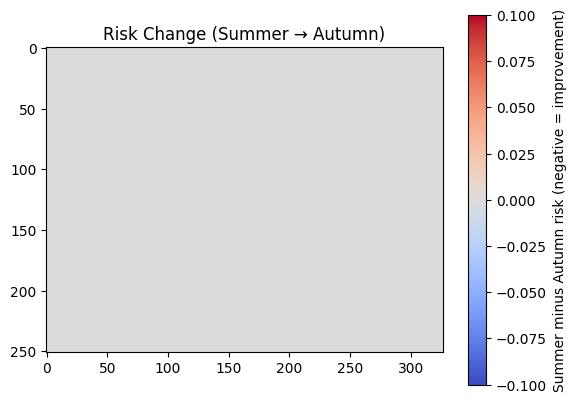

In [ ]:
diff = summer_risk - autumn_risk
plt.imshow(diff, cmap='coolwarm')
plt.colorbar(label='Summer minus Autumn risk (negative = improvement)')
plt.title('Risk Change (Summer → Autumn)')

In [ ]:
print("Summer WQI - min:", summer_wqi_arr.min(), "max:", summer_wqi_arr.max())
print("Autumn WQI - min:", autumn_wqi_arr.min(), "max:", autumn_wqi_arr.max())
print("Mean difference (Summer - Autumn):", (summer_wqi_arr - autumn_wqi_arr).mean())

Summer WQI - min: 45.34671843244418 max: 45.34671844148599
Autumn WQI - min: 21.380204246683213 max: 21.380204249009907
Mean difference (Summer - Autumn): 23.96651418909084


In [ ]:
print("Summer classes - distribution:", np.bincount(summer_wqi_class.flatten()))
print("Autumn classes - distribution:", np.bincount(autumn_wqi_class.flatten()))

Summer classes - distribution: [    0     0 82077]
Autumn classes - distribution: [    0 82077]


In [ ]:
summer_risk = np.zeros_like(summer_wqi_class, dtype=np.uint8)
for (w, g), risk in decision.items():
    mask = (summer_wqi_class == w) & (gwpi_class == g)  # uses summer_wqi_class
    summer_risk[mask] = risk

autumn_risk = np.zeros_like(autumn_wqi_class, dtype=np.uint8)
for (w, g), risk in decision.items():
    mask = (autumn_wqi_class == w) & (gwpi_class == g)  # uses autumn_wqi_class – correct
    autumn_risk[mask] = risk

In [ ]:
decision = {
    # Low risk
    (1,3):1, (1,4):1, (2,3):1, (2,4):1,
    # Low-Moderate (new)
    (1,1):2, (1,2):2, (2,1):2, (2,2):2,
    # Moderate-High (new)
    (3,3):3, (3,4):3, (4,3):3, (4,4):3, (5,3):3, (5,4):3,
    # High
    (3,1):4, (3,2):4, (4,1):4, (4,2):4, (5,1):4, (5,2):4,
}
# Then map 1=Low,2=LowMod,3=ModHigh,4=High – but for plotting, you may collapse or keep 4 colors.

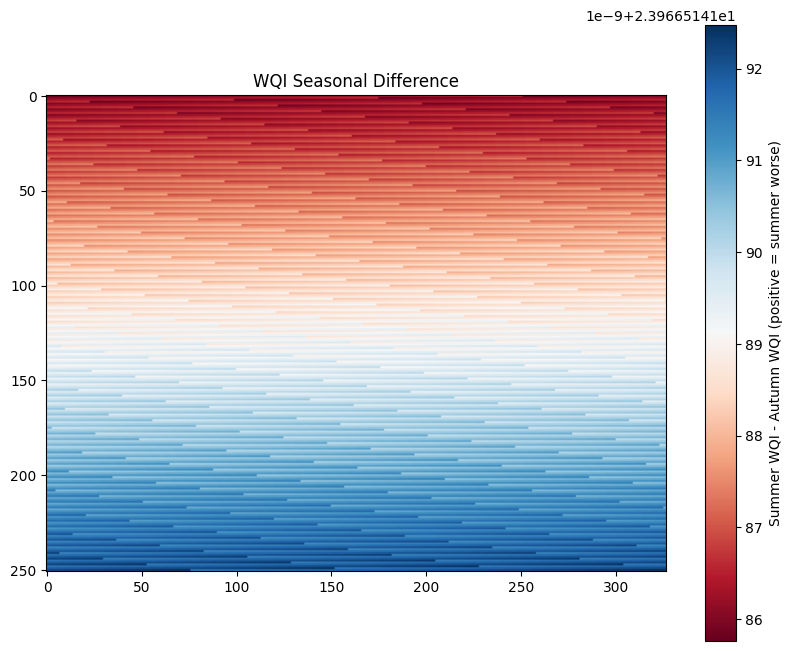

In [ ]:
import matplotlib.pyplot as plt

diff_wqi = summer_wqi_arr - autumn_wqi_arr
plt.figure(figsize=(10,8))
plt.imshow(diff_wqi, cmap='RdBu')
plt.colorbar(label='Summer WQI - Autumn WQI (positive = summer worse)')
plt.title('WQI Seasonal Difference')
plt.show()

In [ ]:
# Simplified decision: risk = (WQI_class - 1) + (GWPI_class - 1)  # gives 0 to 6
# Then map to risk levels: 0-1=Low, 2-3=Moderate, 4-6=High
risk_index = (summer_wqi_class - 1) + (gwpi_class - 1)
summer_risk = np.where(risk_index <= 1, 1, np.where(risk_index <= 3, 2, 3))

risk_index_aut = (autumn_wqi_class - 1) + (gwpi_class - 1)
autumn_risk = np.where(risk_index_aut <= 1, 1, np.where(risk_index_aut <= 3, 2, 3))

In [ ]:
import numpy as np

print("Summer WQI - min: {:.2f}, max: {:.2f}, mean: {:.2f}".format(
    summer_wqi_arr.min(), summer_wqi_arr.max(), summer_wqi_arr.mean()))
print("Autumn WQI - min: {:.2f}, max: {:.2f}, mean: {:.2f}".format(
    autumn_wqi_arr.min(), autumn_wqi_arr.max(), autumn_wqi_arr.mean()))
diff_mean = np.abs(summer_wqi_arr - autumn_wqi_arr).mean()
print("Mean absolute difference: {:.2f}".format(diff_mean))

if diff_mean < 1:
    print("ERROR: WQI rasters are almost identical. Check your CSV files and IDW interpolation.")
else:
    print("OK: WQI rasters differ sufficiently.")

Summer WQI - min: 45.35, max: 45.35, mean: 45.35
Autumn WQI - min: 21.38, max: 21.38, mean: 21.38
Mean absolute difference: 23.97
OK: WQI rasters differ sufficiently.


In [ ]:
# WQI bins: 0-25=1, 26-50=2, 51-75=3, 76-100=4, >100=5
bins_wqi = [0, 25, 50, 75, 100, np.inf]
summer_wqi_class = np.digitize(summer_wqi_arr, bins=bins_wqi, right=False)
autumn_wqi_class = np.digitize(autumn_wqi_arr, bins=bins_wqi, right=False)

print("Summer class distribution (1-5):", np.bincount(summer_wqi_class.flatten())[1:])
print("Autumn class distribution (1-5):", np.bincount(autumn_wqi_class.flatten())[1:])

# GWPI bins: 0-2=1, 2-3=2, 3-4=3, 4-5=4
bins_gwpi = [0, 2, 3, 4, 5]
gwpi_class = np.digitize(gw_array, bins=bins_gwpi, right=False)
gwpi_class = np.nan_to_num(gwpi_class, nan=0).astype(np.uint8)
print("GWPI class distribution (1-4):", np.bincount(gwpi_class.flatten())[1:])

Summer class distribution (1-5): [    0 82077]
Autumn class distribution (1-5): [82077]
GWPI class distribution (1-4): [  135 22617 15545  1036 42744]


In [ ]:
decision = {
    # Low risk (1): Good/Excellent WQI + Good/Excellent potential
    (1,3):1, (1,4):1, (2,3):1, (2,4):1,
    # Moderate risk (2): Good WQI + Poor/Fair potential OR Poor WQI + Good/Excellent potential
    (1,1):2, (1,2):2, (2,1):2, (2,2):2,
    (3,3):2, (3,4):2, (4,3):2, (4,4):2, (5,3):2, (5,4):2,
    # High risk (3): Poor/Unfit WQI + Poor/Fair potential
    (3,1):3, (3,2):3, (4,1):3, (4,2):3, (5,1):3, (5,2):3,
}

In [ ]:
# Summer risk
summer_risk = np.zeros_like(summer_wqi_class, dtype=np.uint8)
for (w, g), risk in decision.items():
    mask = (summer_wqi_class == w) & (gwpi_class == g)
    summer_risk[mask] = risk

# Autumn risk
autumn_risk = np.zeros_like(autumn_wqi_class, dtype=np.uint8)
for (w, g), risk in decision.items():
    mask = (autumn_wqi_class == w) & (gwpi_class == g)
    autumn_risk[mask] = risk

# Check if they differ
diff_frac = np.mean(summer_risk != autumn_risk)
print(f"Fraction of pixels where risk differs: {diff_frac:.2%}")

# If still identical (0%), use fallback additive method
if diff_frac == 0:
    print("WARNING: Risk rasters identical. Using additive risk formula.")
    # Additive risk: (WQI_class-1) + (GWPI_class-1) -> 0..6, then map to 1-3
    summer_idx = (summer_wqi_class - 1) + (gwpi_class - 1)
    autumn_idx = (autumn_wqi_class - 1) + (gwpi_class - 1)
    summer_risk = np.where(summer_idx <= 1, 1, np.where(summer_idx <= 3, 2, 3))
    autumn_risk = np.where(autumn_idx <= 1, 1, np.where(autumn_idx <= 3, 2, 3))
    print("Fallback risk unique values (summer):", np.unique(summer_risk))
    print("Fallback risk unique values (autumn):", np.unique(autumn_risk))

Fraction of pixels where risk differs: 0.00%
Fallback risk unique values (summer): [1 2 3]
Fallback risk unique values (autumn): [1 2 3]


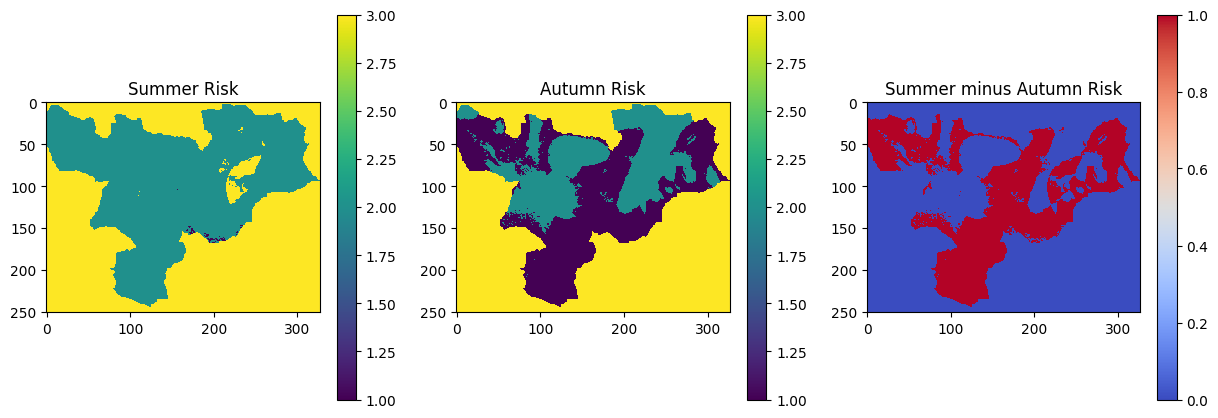

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im1 = axes[0].imshow(summer_risk, cmap='viridis', interpolation='none')
axes[0].set_title('Summer Risk')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(autumn_risk, cmap='viridis', interpolation='none')
axes[1].set_title('Autumn Risk')
plt.colorbar(im2, ax=axes[1])

diff_map = summer_risk - autumn_risk
im3 = axes[2].imshow(diff_map, cmap='coolwarm', interpolation='none')
axes[2].set_title('Summer minus Autumn Risk')
plt.colorbar(im3, ax=axes[2])
plt.show()

In [ ]:
import rasterio

# Save the summer masked risk map
with rasterio.open('summer_risk_map_clipped.tif', 'w', **summer_meta) as dst:
    dst.write(summer_masked, 1)

# Save the autumn masked risk map
with rasterio.open('autumn_risk_map_clipped.tif', 'w', **autumn_meta) as dst:
    dst.write(autumn_masked, 1)

print("Clipped risk maps saved as summer_risk_map_clipped.tif and autumn_risk_map_clipped.tif")


Clipped risk maps saved as summer_risk_map_clipped.tif and autumn_risk_map_clipped.tif


In [ ]:
from google.colab import files

# Download summer risk map
files.download('summer_risk_map.tif')

# Download autumn risk map
files.download('autumn_risk_map.tif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import zipfile
import os

# Create a zip file
with zipfile.ZipFile('risk_maps.zip', 'w') as zipf:
    zipf.write('summer_risk_map.tif')
    zipf.write('autumn_risk_map.tif')

# Download the zip
files.download('risk_maps.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Download summer risk PNG
files.download('Figure_5.1_Summer_Risk_Map.png')

# Download autumn risk PNG
files.download('Figure_5.2_Autumn_Risk_Map.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>